# Mini Project Notebook: Credit Card Clustering

## Dr. Prashanth Kannadaguli
### Founding Chief Research Architect & President
### Dhaarini AI-Tech Research Academy, Bengaluru, India

In [1]:
# Load the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')


## Dataset Exploration



Load the dataset "CreditCards.csv" into a Pandas DataFrame. Display the first 15 rows and all columns.

In [2]:
# Load dataset CreditCards.xlsx (uploaded to /content/sample_data/ in Colab)
FILE_PATH = '/content/sample_data/CreditCards.xlsx'

df = pd.read_excel(FILE_PATH)

print("Shape of dataset:", df.shape)
df.head(15)


Shape of dataset: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


Determine the data types of each column in the DataFrame. Check for missing values and count the number of missing values in each column.

In [3]:
# Data types of each column
print("Data types of each column:\n")
print(df.dtypes)

# Missing values per column
print("\nMissing values per column:\n")
print(df.isnull().sum())


Data types of each column:

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Missing values per column:

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES        

Check the data types of all columns and ensure they are consistent with the expected types (e.g., numerical for quantities, categorical for identifiers).

In [4]:
# Check data types are consistent with expected types
# CUST_ID should be an identifier (object/string); everything else should be numeric
print(df.dtypes)
print("\nColumns that are 'object' type (should typically just be CUST_ID):")
print(df.select_dtypes(include='object').columns.tolist())


CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Columns that are 'object' type (should typically just be CUST_ID):
['CUST_ID']


Convert data types if necessary (e.g., convert object columns to numeric if appropriate).

In [5]:
# Convert data types if necessary
# Force all columns except CUST_ID to numeric, coercing any bad values to NaN
id_cols = [c for c in df.columns if 'CUST_ID' in c.upper() or df[c].dtype == 'object']

for col in df.columns:
    if col not in id_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)


CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


Calculate summary statistics (mean, median, mode, standard deviation, min, max, quartiles) for numerical columns.

In [6]:
# Summary statistics for numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

summary = df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['mode'] = df[numeric_cols].mode().iloc[0]

summary


,count,mean,std,min,25%,50%,75%,max,median,mode
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856,873.385231,0.000000
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000,1.000000,1.000000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000,361.280000,0.000000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000,38.000000,0.000000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000,89.000000,0.000000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176,0.000000,0.000000
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000,0.500000,1.000000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000,0.083333,0.000000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000,0.166667,0.000000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000,0.000000,0.000000


Calculate the correlation between numerical variables. Visualize the correlation matrix using a heatmap.

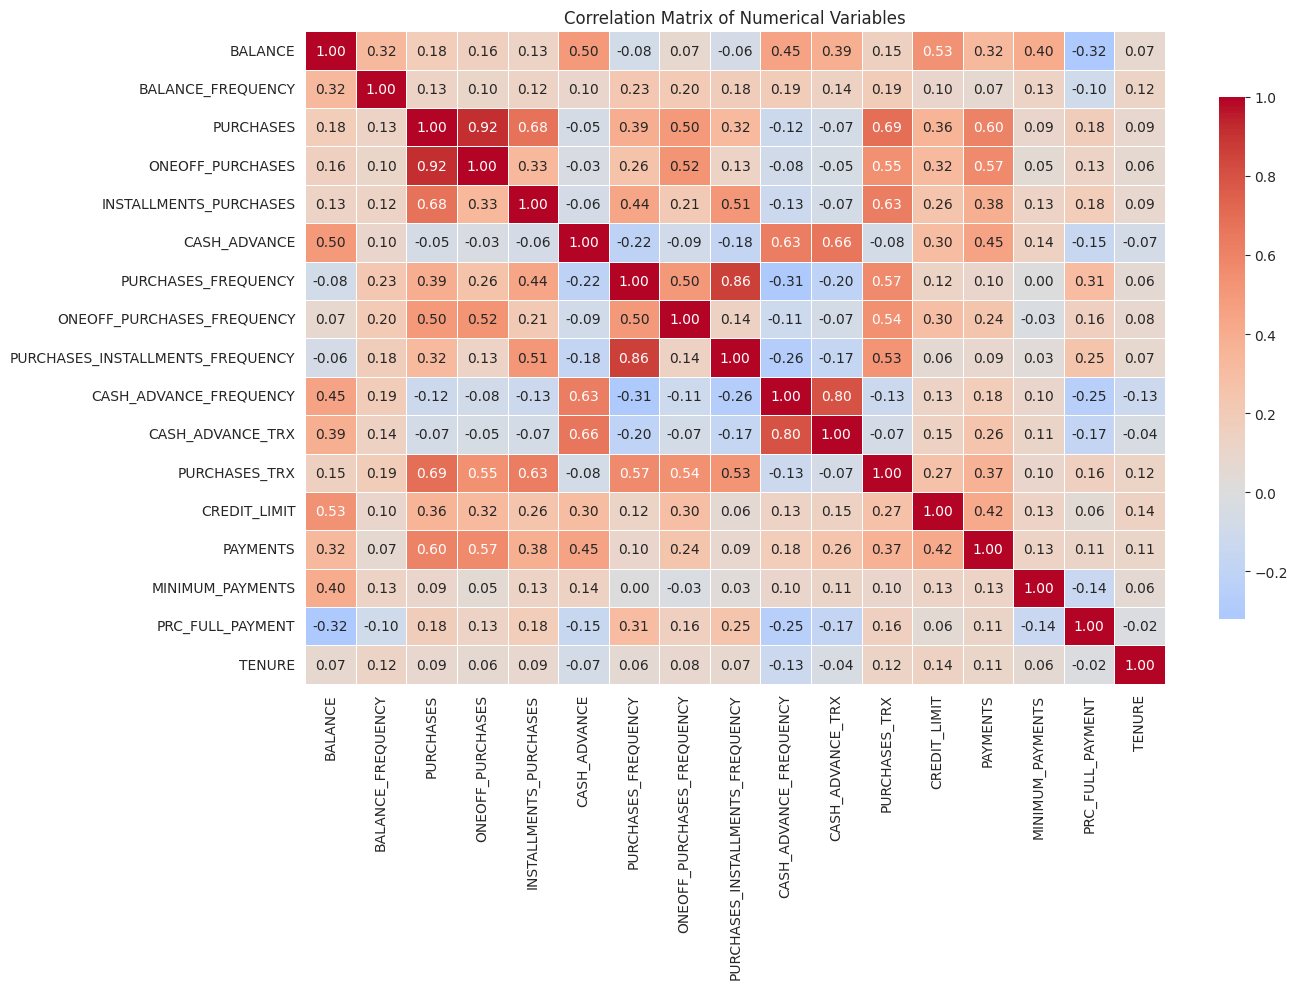

In [7]:
# Correlation matrix and heatmap
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()


Analyze the distribution of categorical variables (e.g., count the occurrences of different values in the CUST_ID column).

In [8]:
# Distribution of the identifier / categorical column
id_col = id_cols[0] if id_cols else df.columns[0]
print(f"Column analyzed: {id_col}")
print(f"Number of unique values: {df[id_col].nunique()}")
print(f"Total rows: {len(df)}")
print("\nSince CUST_ID is a unique identifier for each customer, every value occurs exactly once.")
print(df[id_col].value_counts().head(10))


Column analyzed: CUST_ID
Number of unique values: 8950
Total rows: 8950

Since CUST_ID is a unique identifier for each customer, every value occurs exactly once.
CUST_ID
C19190    1
C10001    1
C10002    1
C10003    1
C10004    1
C10005    1
C19174    1
C19173    1
C19172    1
C19171    1
Name: count, dtype: int64


Identify outliers using box plots or statistical methods (e.g., IQR).

                                  n_outliers  pct_outliers
BALANCE_FREQUENCY                       1493         16.68
PRC_FULL_PAYMENT                        1474         16.47
TENURE                                  1366         15.26
CASH_ADVANCE                            1030         11.51
ONEOFF_PURCHASES                        1013         11.32
INSTALLMENTS_PURCHASES                   867          9.69
MINIMUM_PAYMENTS                         841          9.40
PAYMENTS                                 808          9.03
PURCHASES                                808          9.03
CASH_ADVANCE_TRX                         804          8.98
ONEOFF_PURCHASES_FREQUENCY               782          8.74
PURCHASES_TRX                            766          8.56
BALANCE                                  695          7.77
CASH_ADVANCE_FREQUENCY                   525          5.87
CREDIT_LIMIT                             248          2.77
PURCHASES_INSTALLMENTS_FREQUENCY           0          0.

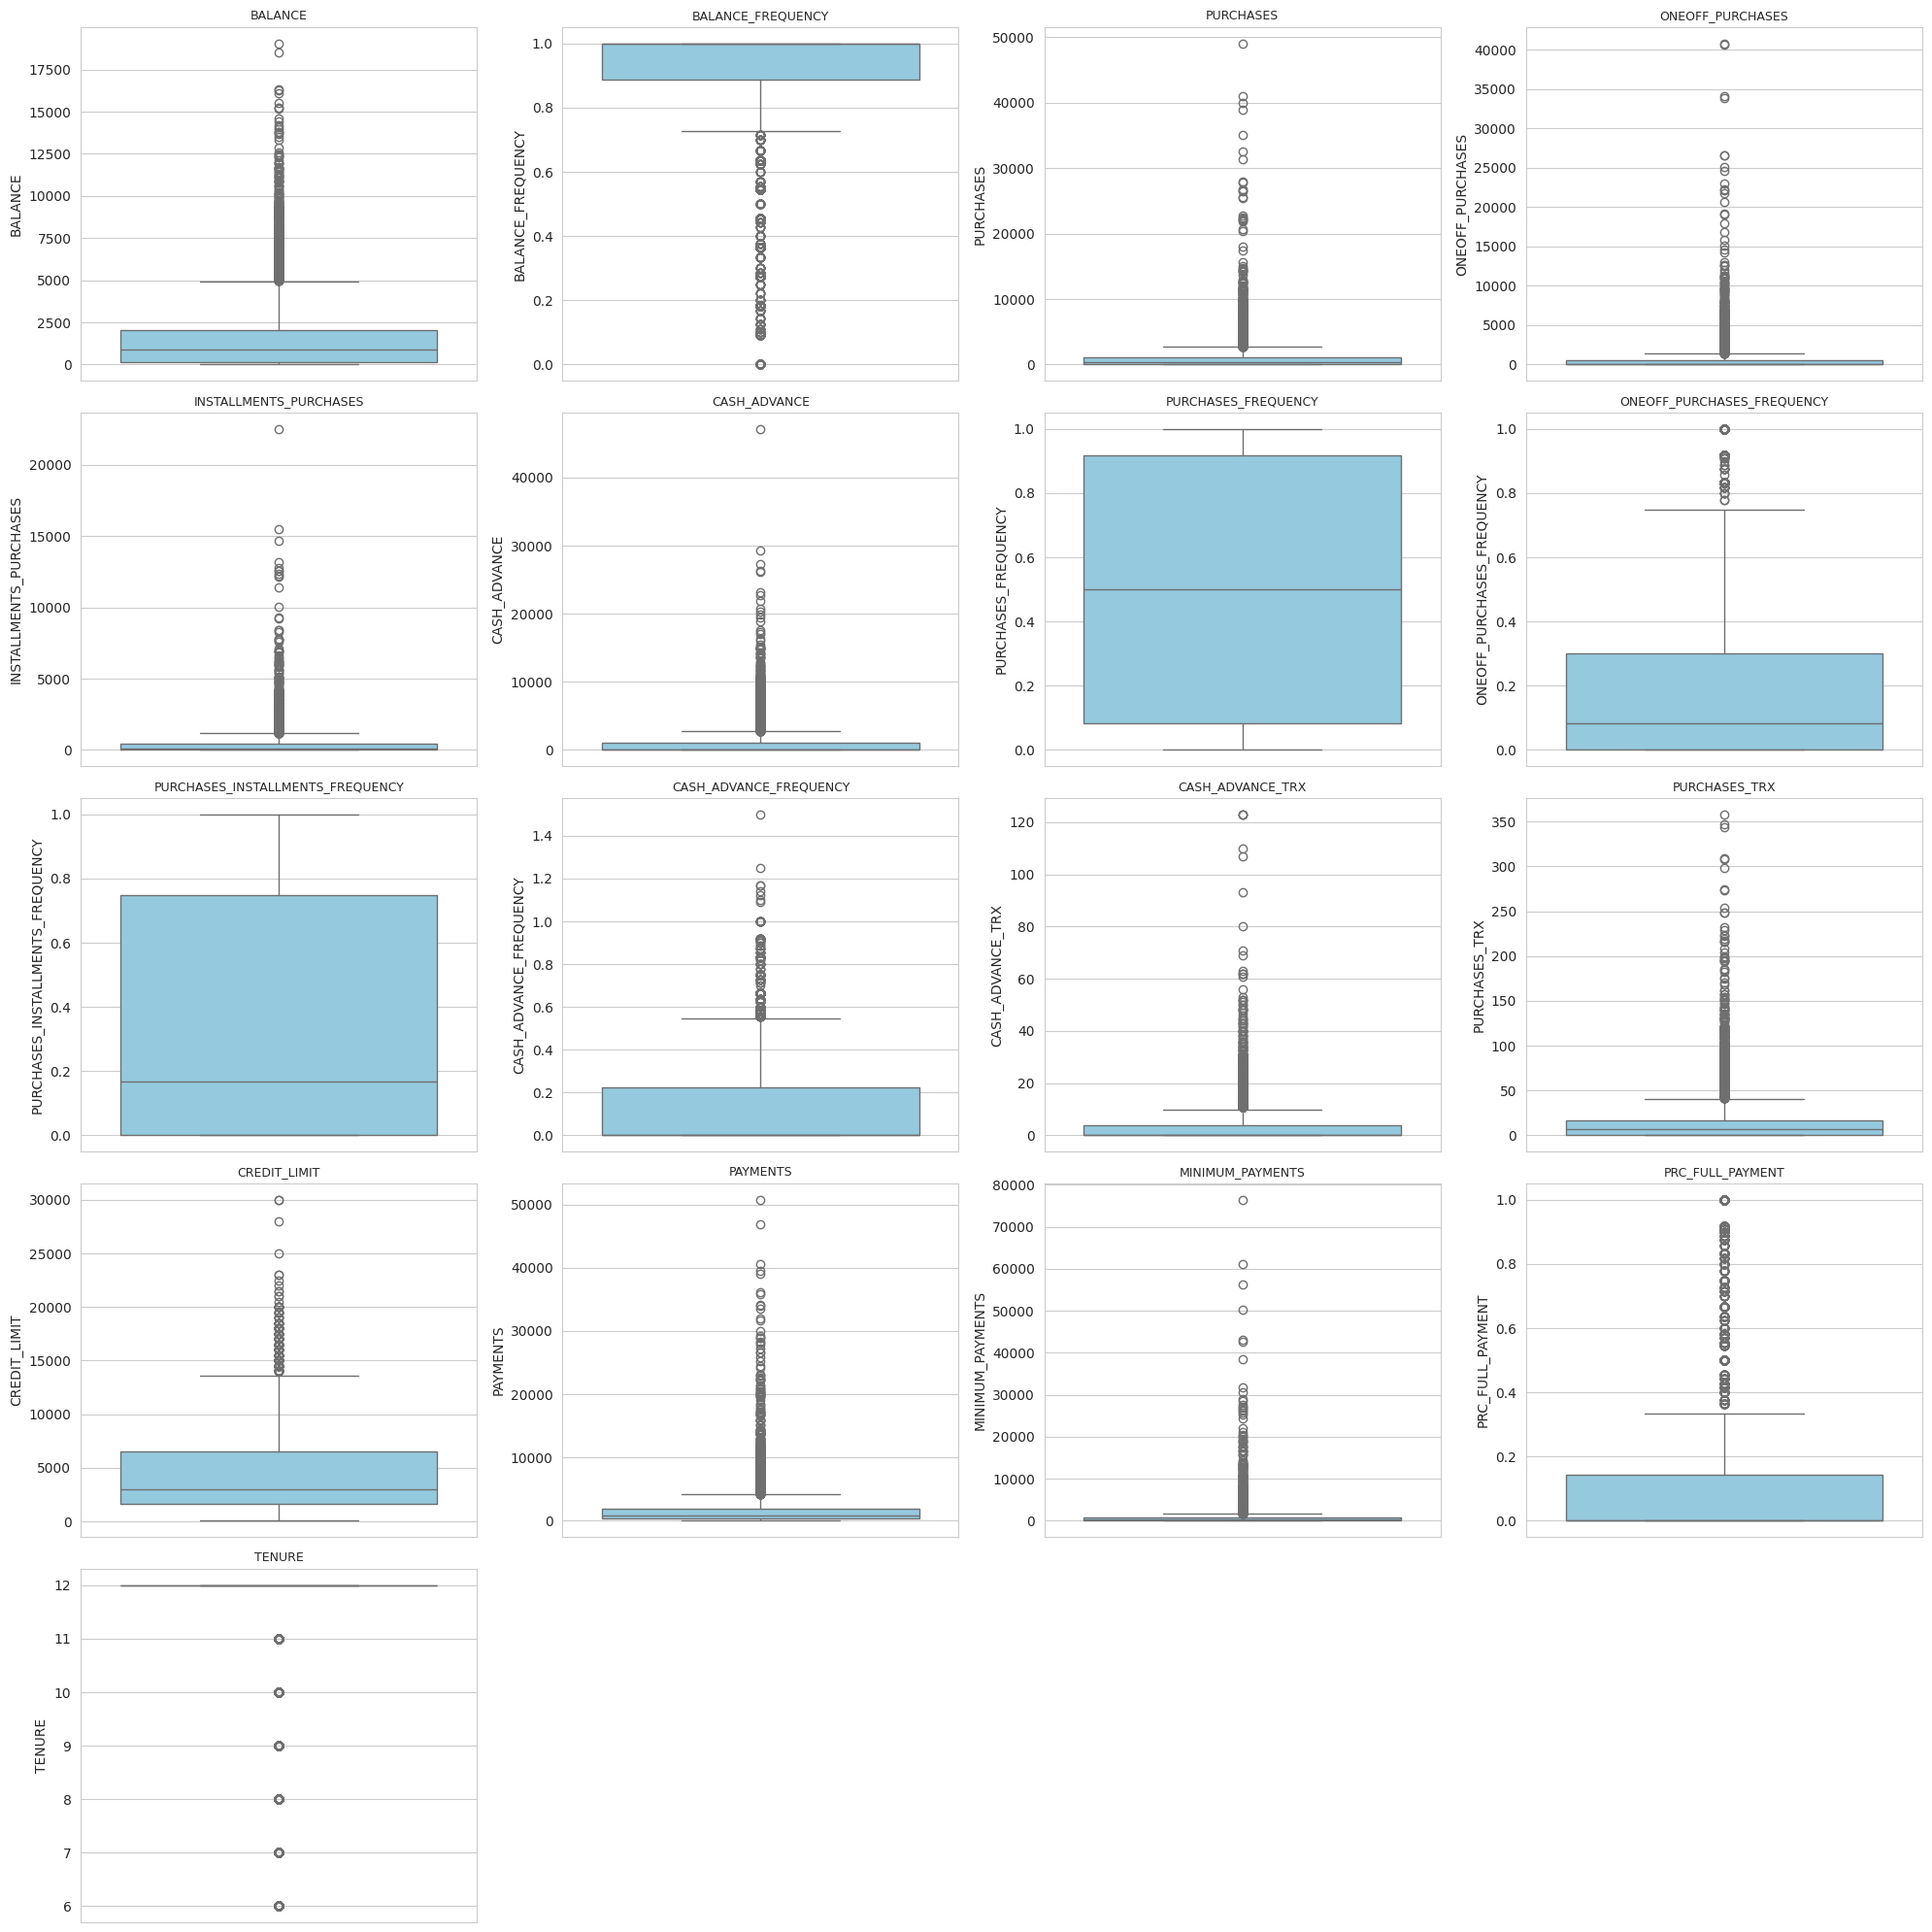

In [9]:
# Identify outliers using box plots and IQR method
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['n_outliers'])
outlier_df['pct_outliers'] = (outlier_df['n_outliers'] / len(df) * 100).round(2)
print(outlier_df.sort_values('pct_outliers', ascending=False))

# Box plots for all numeric columns
fig, axes = plt.subplots(nrows=(len(numeric_cols)+3)//4, ncols=4, figsize=(20, 4*((len(numeric_cols)+3)//4)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


Visualize the impact of outliers: Remove outliers and re-visualize the data to assess their impact on the overall distribution and relationships.

Original shape: (8950, 18)
Shape after outlier removal: (2035, 18)
Rows removed: 6915 (77.3%)


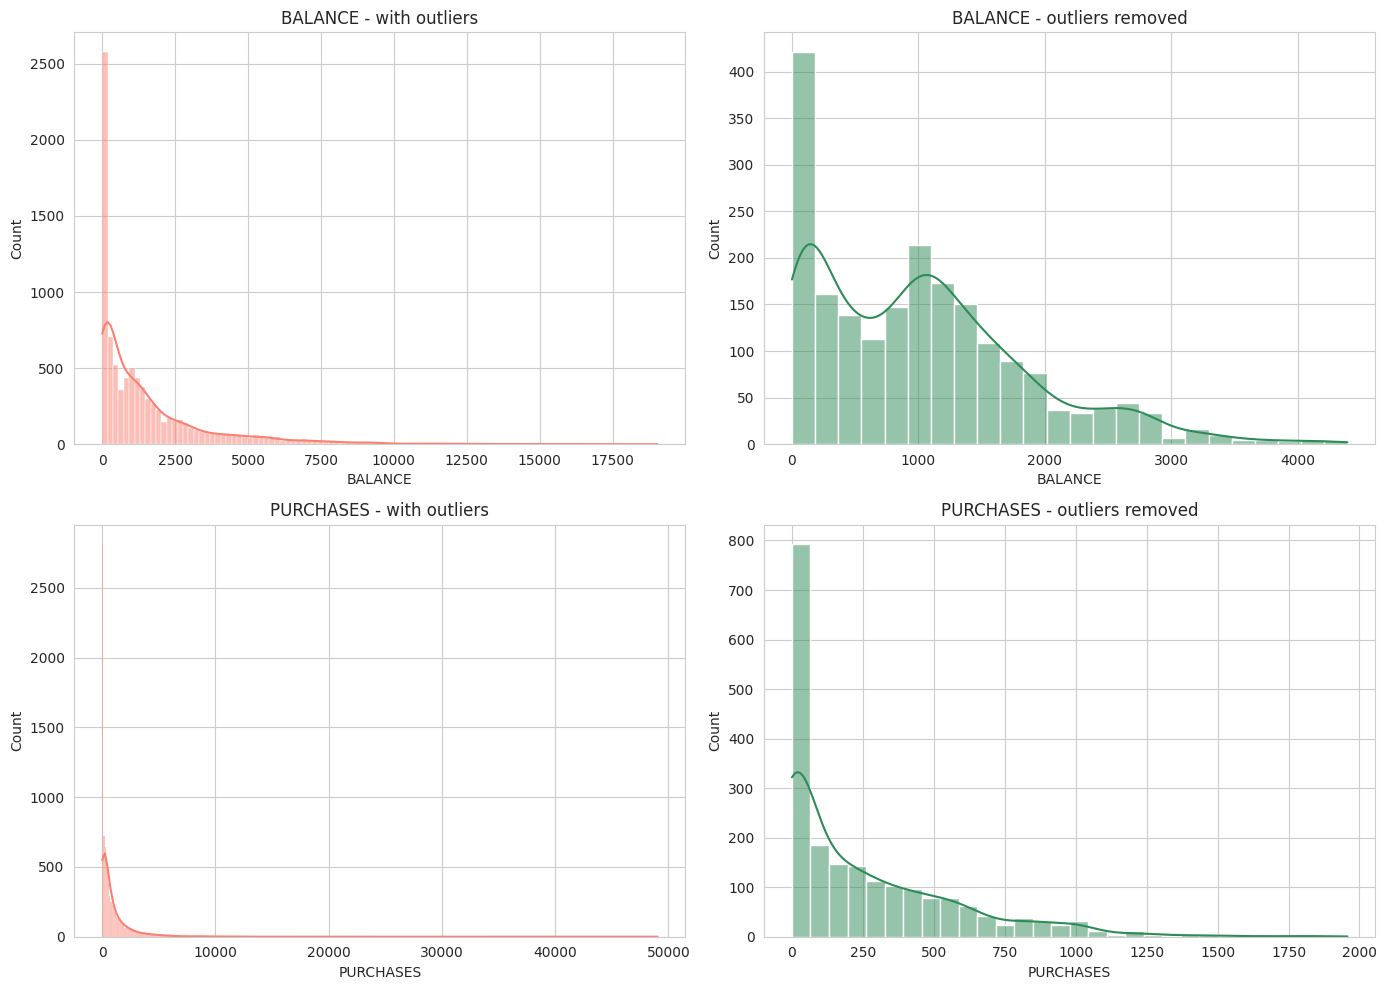

In [10]:
# Remove outliers (using IQR method) and re-visualize
def remove_outliers_iqr(data, cols, factor=1.5):
    data_clean = data.copy()
    for col in cols:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        data_clean = data_clean[(data_clean[col] >= lower) & (data_clean[col] <= upper)]
    return data_clean

df_no_outliers = remove_outliers_iqr(df, numeric_cols)
print(f"Original shape: {df.shape}")
print(f"Shape after outlier removal: {df_no_outliers.shape}")
print(f"Rows removed: {df.shape[0] - df_no_outliers.shape[0]} "
      f"({(df.shape[0]-df_no_outliers.shape[0])/df.shape[0]*100:.1f}%)")

# Compare distribution before/after for a couple of key variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['BALANCE'], ax=axes[0,0], kde=True, color='salmon').set_title('BALANCE - with outliers')
sns.histplot(df_no_outliers['BALANCE'], ax=axes[0,1], kde=True, color='seagreen').set_title('BALANCE - outliers removed')
sns.histplot(df['PURCHASES'], ax=axes[1,0], kde=True, color='salmon').set_title('PURCHASES - with outliers')
sns.histplot(df_no_outliers['PURCHASES'], ax=axes[1,1], kde=True, color='seagreen').set_title('PURCHASES - outliers removed')
plt.tight_layout()
plt.show()

# Note: aggressively removing outliers on EVERY column can drop most of the dataset
# (since credit-card spending data is naturally skewed). For modeling we will instead
# CAP outliers later rather than deleting rows outright.


Identify missing values in the dataset and calculate the percentage of missing data for each column.

In [11]:
# Percentage of missing data per column
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': df.isnull().sum(), 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_summary)


                  missing_count  missing_pct
MINIMUM_PAYMENTS            313         3.50
CREDIT_LIMIT                  1         0.01


Handle missing values (e.g., imputation, deletion) and outliers (e.g., capping, removal).

In [12]:
# Handle missing values via median imputation (robust to skew/outliers)
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

print("Missing values remaining:\n", df.isnull().sum().sum())

# Handle outliers via capping (winsorization) at the 1st/99th percentile instead of deleting rows
def cap_outliers(data, cols, lower_q=0.01, upper_q=0.99):
    data = data.copy()
    for col in cols:
        lower = data[col].quantile(lower_q)
        upper = data[col].quantile(upper_q)
        data[col] = data[col].clip(lower, upper)
    return data

df_capped = cap_outliers(df, numeric_cols)
print("\nOutliers capped at 1st/99th percentile. Example - BALANCE stats before vs after:")
print(pd.DataFrame({'before': df['BALANCE'].describe(), 'after': df_capped['BALANCE'].describe()}))


Missing values remaining:
 0

Outliers capped at 1st/99th percentile. Example - BALANCE stats before vs after:
             before        after
count   8950.000000  8950.000000
mean    1564.474828  1541.046707
std     2081.531879  1966.597484
min        0.000000     0.065101
25%      128.281915   128.281915
50%      873.385231   873.385231
75%     2054.140036  2054.140036
max    19043.138560  9338.804814


For categorical columns, impute missing values with the most frequent category or a new category.

In [13]:
# Impute missing values for categorical columns with the most frequent category
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if categorical_cols:
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
    print("Categorical columns imputed:", categorical_cols)
else:
    print("No categorical columns with missing values in this dataset "
          "(CUST_ID is the only object column and is a unique identifier, not typically missing).")


Categorical columns imputed: ['CUST_ID']


Explore the relationship between categorical variables and numerical variables (e.g., calculate the average BALANCE for different CUST_ID categories).

TENURE
6     1095.890702
7     1003.800362
8     1127.963470
9     1098.752149
10    1251.955773
11    1641.770893
12    1619.158166
Name: BALANCE, dtype: float64


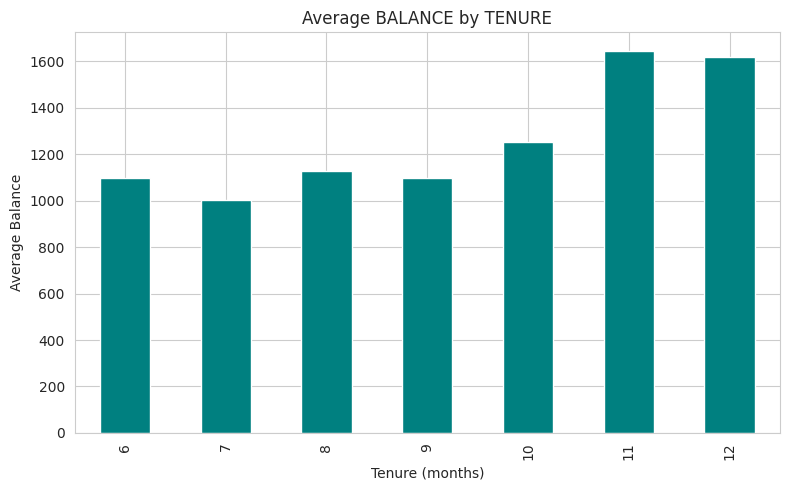

In [14]:
# Relationship between a categorical grouping (TENURE, since CUST_ID is unique per row)
# and a numerical variable (BALANCE)
if 'TENURE' in df.columns:
    avg_balance_by_tenure = df.groupby('TENURE')['BALANCE'].mean().sort_index()
    print(avg_balance_by_tenure)

    plt.figure(figsize=(8, 5))
    avg_balance_by_tenure.plot(kind='bar', color='teal')
    plt.title('Average BALANCE by TENURE')
    plt.xlabel('Tenure (months)')
    plt.ylabel('Average Balance')
    plt.tight_layout()
    plt.show()
else:
    print("TENURE column not found; showing average BALANCE overall instead.")
    print(df['BALANCE'].mean())


Analyze the distribution of categorical variables conditioned on other categorical variables (e.g., how many customers with a high credit limit also have a high purchase frequency?).

PURCHASE_FREQ_LEVEL   Low  High
CREDIT_LIMIT_LEVEL             
Low                  2520  2064
High                 1955  2411


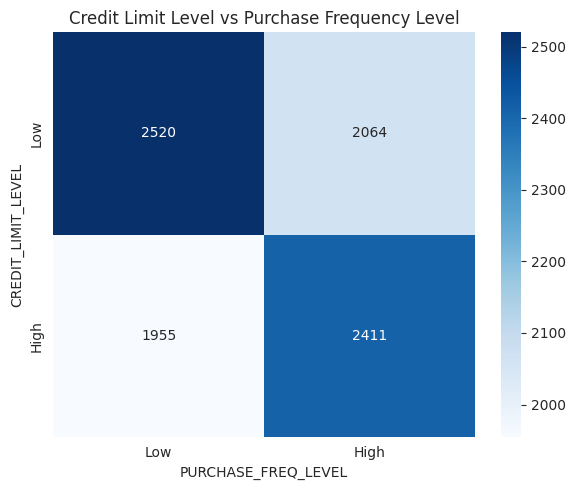

In [15]:
# Cross-tabulation: high credit limit vs high purchase frequency
if 'CREDIT_LIMIT' in df.columns and 'PURCHASES_FREQUENCY' in df.columns:
    df['CREDIT_LIMIT_LEVEL'] = pd.qcut(df['CREDIT_LIMIT'], q=2, labels=['Low', 'High'])
    df['PURCHASE_FREQ_LEVEL'] = pd.qcut(df['PURCHASES_FREQUENCY'].rank(method='first'), q=2, labels=['Low', 'High'])

    cross_tab = pd.crosstab(df['CREDIT_LIMIT_LEVEL'], df['PURCHASE_FREQ_LEVEL'])
    print(cross_tab)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
    plt.title('Credit Limit Level vs Purchase Frequency Level')
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found.")


Explore the relationship between categorical variables and time-based features (e.g., how does the average purchase amount change over time for different customer segments?).

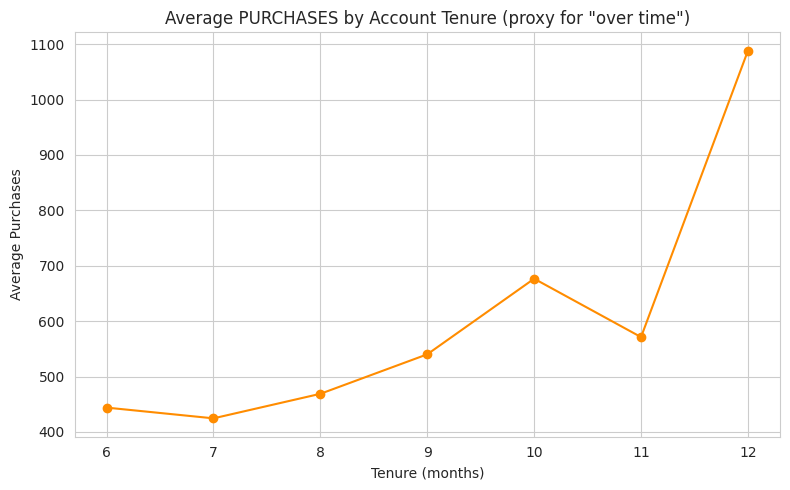

In [16]:
# This dataset is a static (cross-sectional) snapshot per customer - it does not contain
# a transaction-level date/timestamp column, so we cannot trend purchase amount "over time".
# As a proxy, we look at how average PURCHASES varies across TENURE (how long the account
# has been open), which is the closest available "time" dimension.
if 'TENURE' in df.columns and 'PURCHASES' in df.columns:
    avg_purchases_by_tenure = df.groupby('TENURE')['PURCHASES'].mean().sort_index()
    plt.figure(figsize=(8, 5))
    avg_purchases_by_tenure.plot(marker='o', color='darkorange')
    plt.title('Average PURCHASES by Account Tenure (proxy for "over time")')
    plt.xlabel('Tenure (months)')
    plt.ylabel('Average Purchases')
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found.")


Identify any patterns or trends in the data that might be relevant for customer segmentation (e.g., are there specific groups of customers with similar purchasing behaviors?).

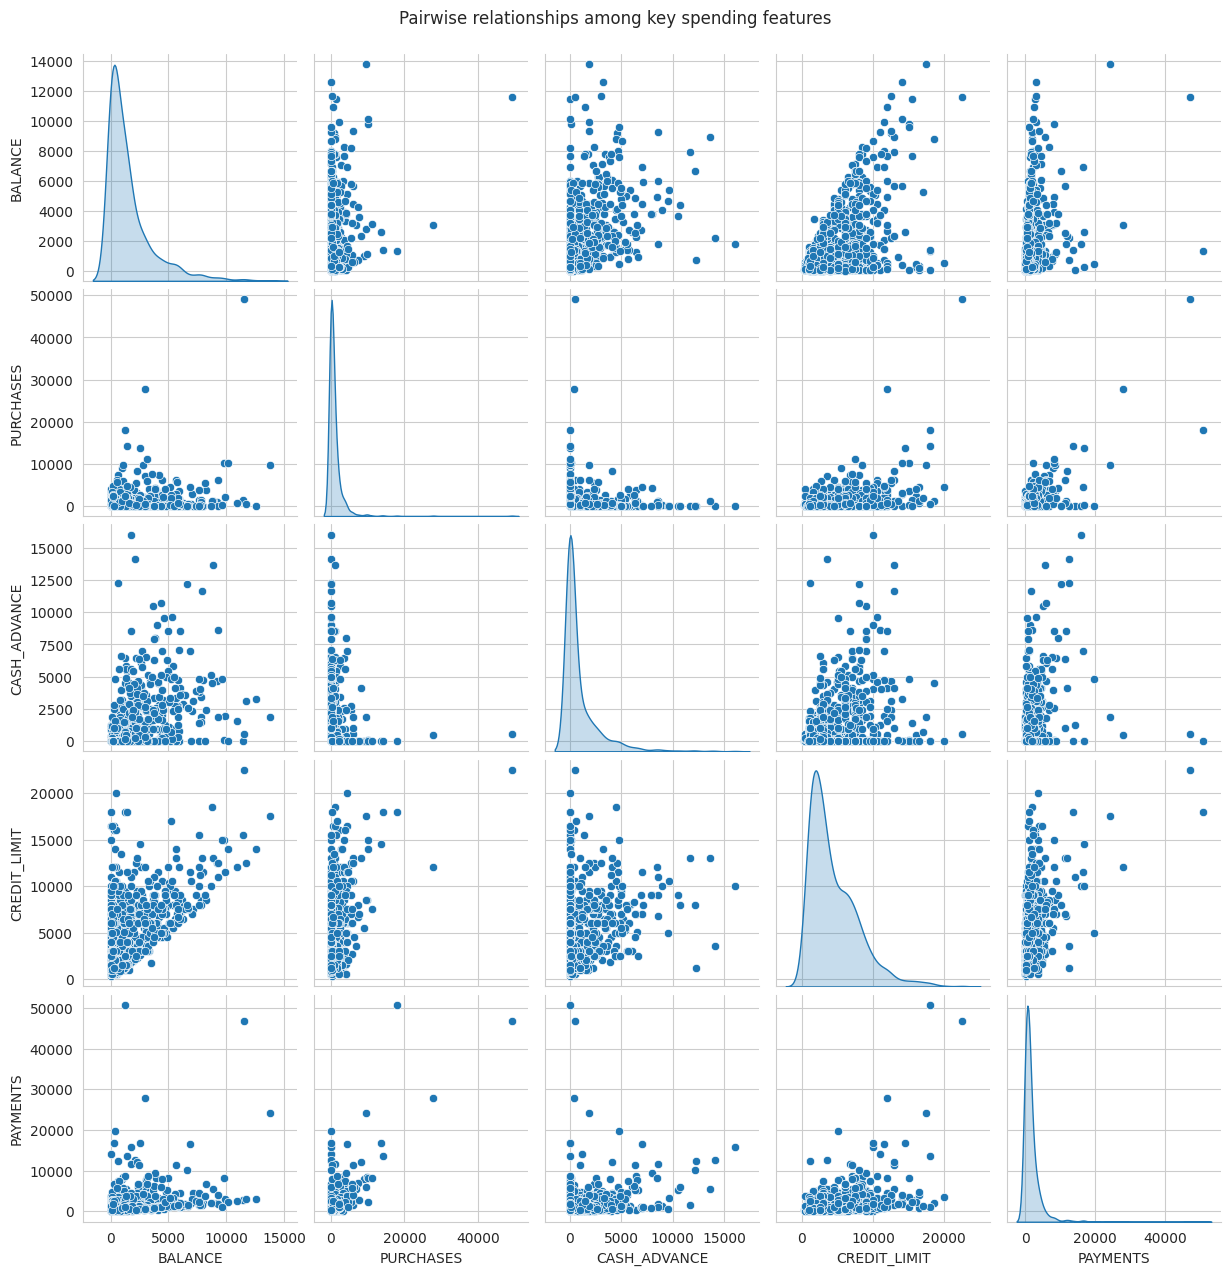

Observation: customers with high BALANCE and high CASH_ADVANCE but low PURCHASES look different from customers who have high PURCHASES but low CASH_ADVANCE - suggesting at least a 'revolvers vs transactors' style segmentation.


In [17]:
# Look for patterns relevant to segmentation: relate spend-related features to each other
segment_features = [c for c in ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS'] if c in df.columns]

sns.pairplot(df[segment_features].sample(min(1000, len(df)), random_state=42), diag_kind='kde')
plt.suptitle('Pairwise relationships among key spending features', y=1.02)
plt.show()

print("Observation: customers with high BALANCE and high CASH_ADVANCE but low PURCHASES look "
      "different from customers who have high PURCHASES but low CASH_ADVANCE - suggesting at "
      "least a 'revolvers vs transactors' style segmentation.")


Visualize the distribution of numerical variables using histograms or box plots to identify outliers or skewness in the data.

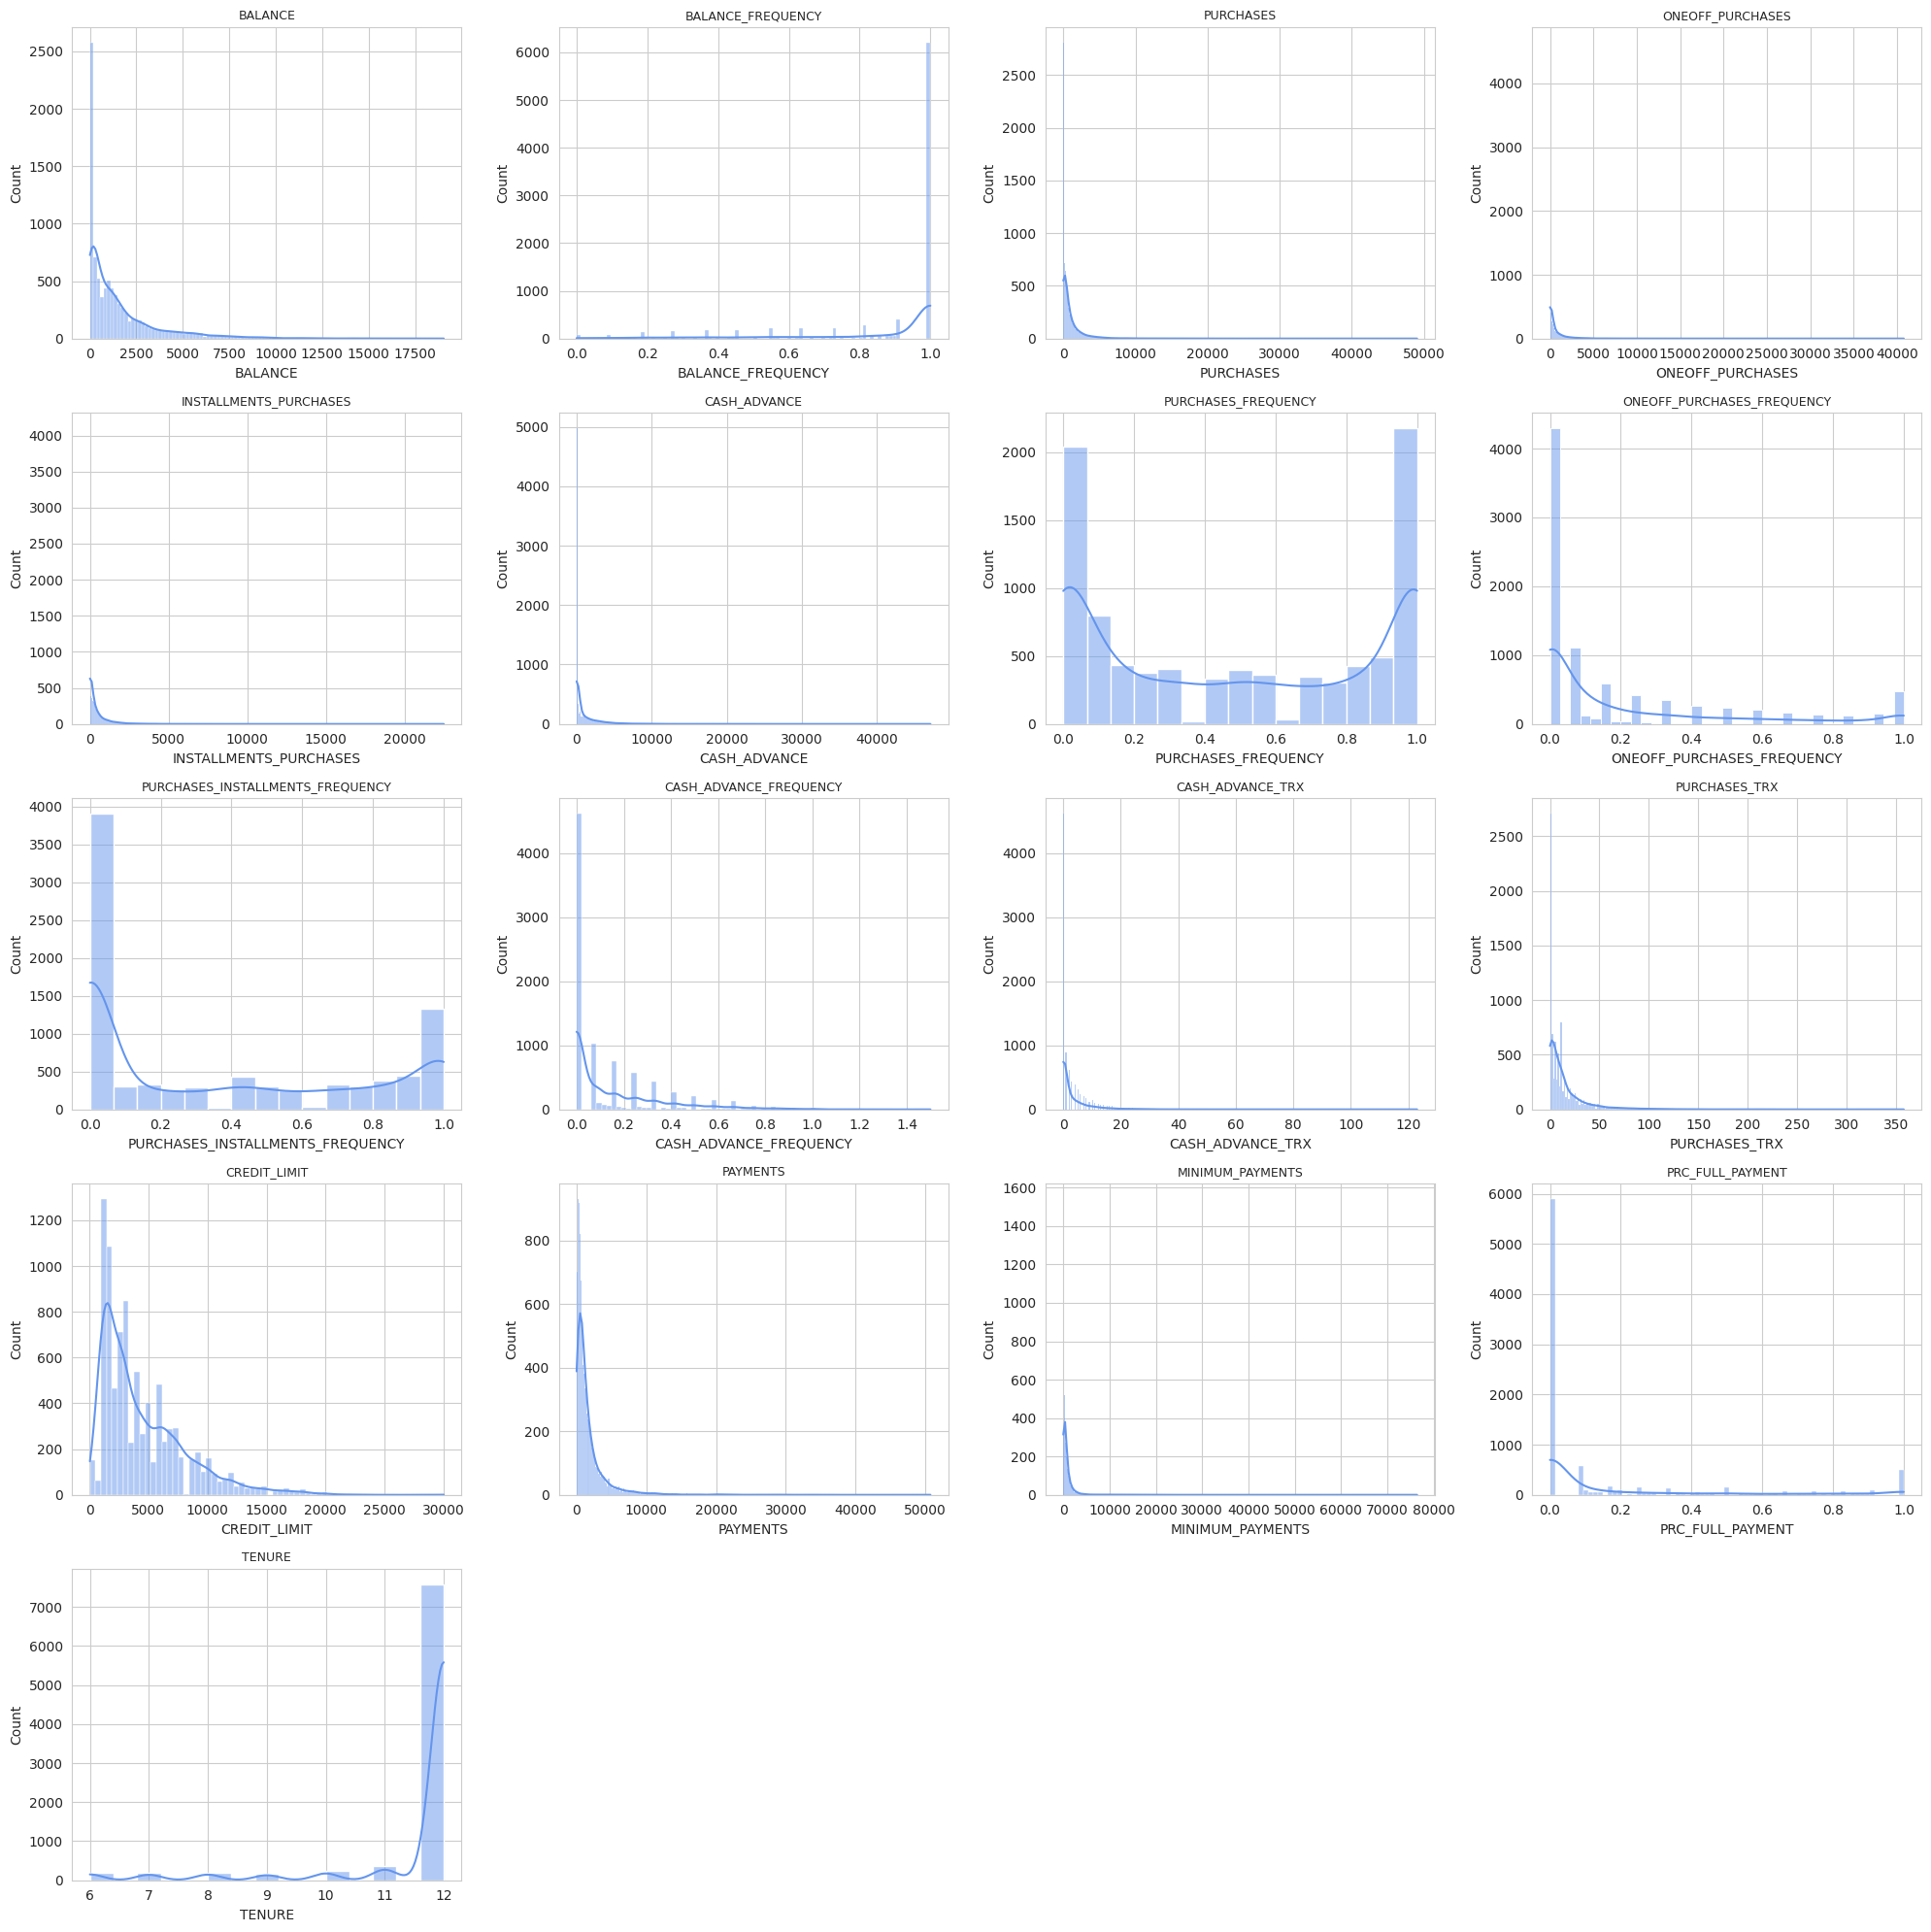

In [18]:
# Histograms and box plots for all numerical variables to check outliers/skewness
fig, axes = plt.subplots(nrows=(len(numeric_cols)+3)//4, ncols=4, figsize=(20, 4*((len(numeric_cols)+3)//4)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='cornflowerblue')
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


## EDA

Visualize the distribution of numerical variables: Create histograms, box plots, and density plots to understand the shape, central tendency, and spread of variables like BALANCE, PURCHASES, and ONEOFF_PURCHASES.

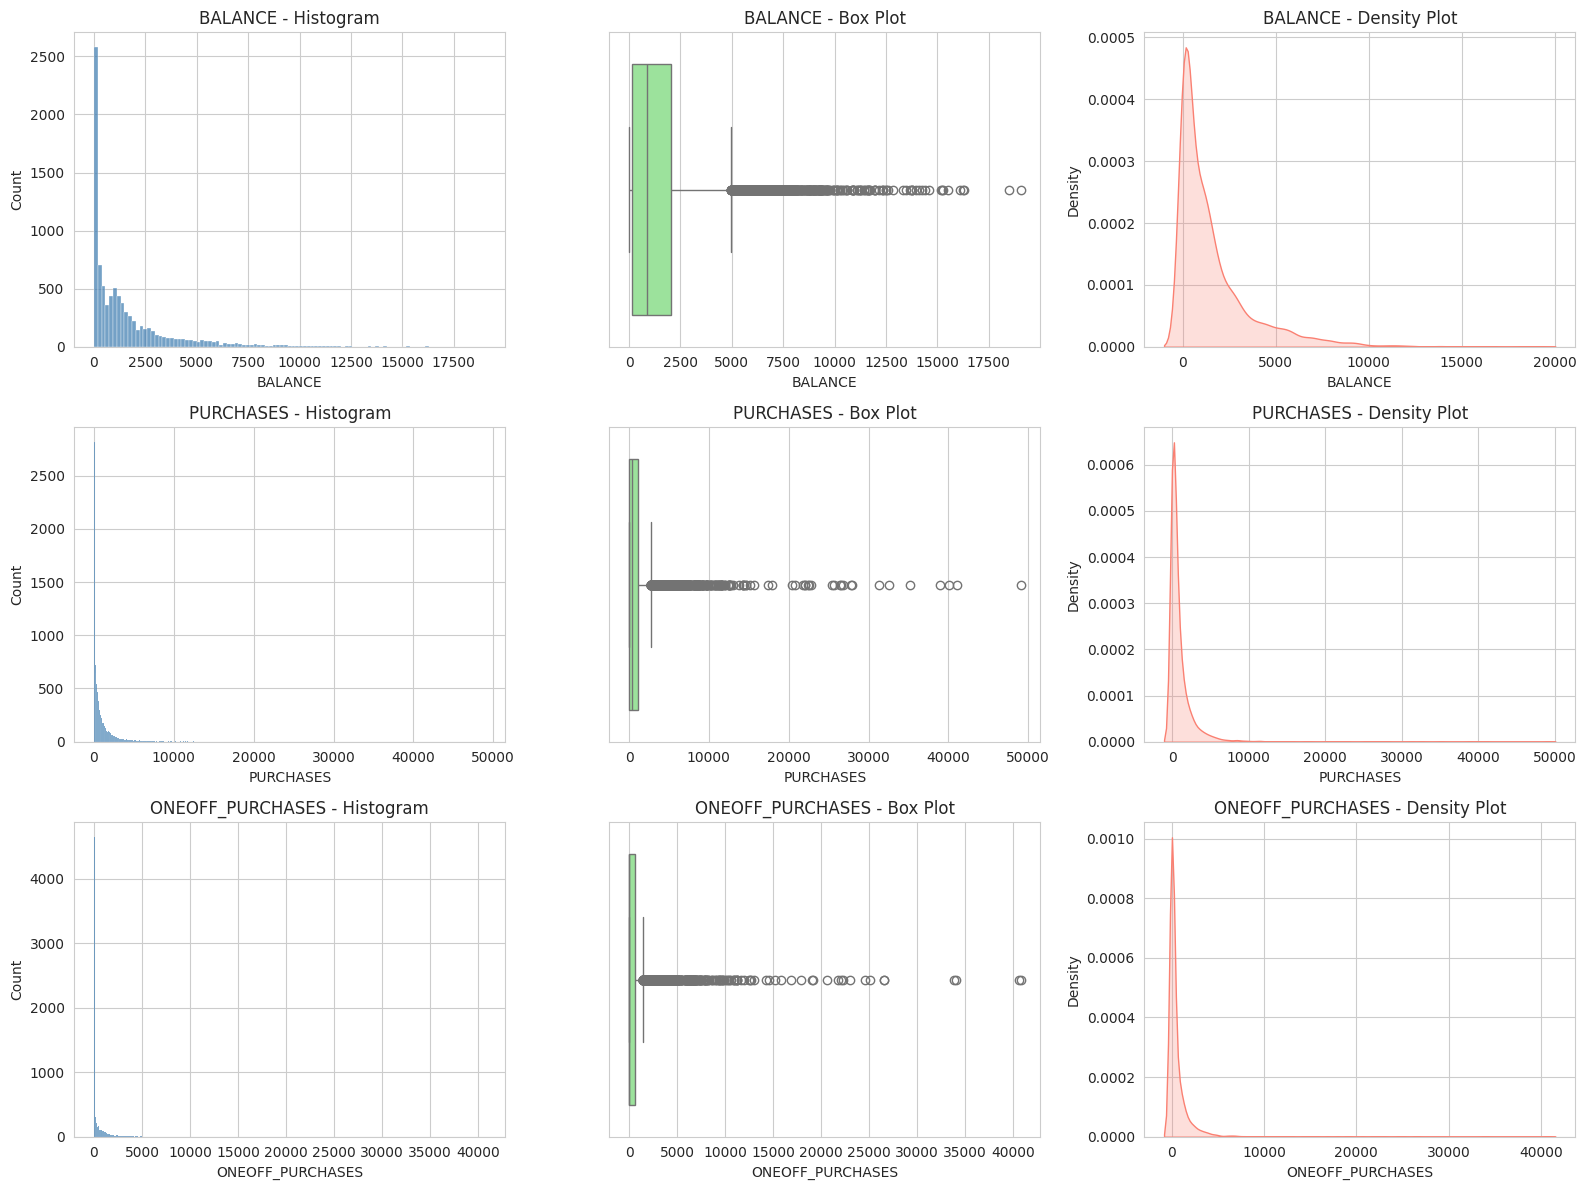

In [19]:
# Histograms, box plots, and density plots for BALANCE, PURCHASES, ONEOFF_PURCHASES
key_vars = [c for c in ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES'] if c in df.columns]

fig, axes = plt.subplots(len(key_vars), 3, figsize=(16, 4*len(key_vars)))
for i, col in enumerate(key_vars):
    sns.histplot(df[col], ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{col} - Histogram')

    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col} - Box Plot')

    sns.kdeplot(df[col], ax=axes[i, 2], fill=True, color='salmon')
    axes[i, 2].set_title(f'{col} - Density Plot')
plt.tight_layout()
plt.show()


Visualize the distribution of categorical variables: Create bar charts or pie charts to show the frequency of different categories in variables like CUST_ID, PURCHASES_FREQUENCY, and CASHADVANCEFREQUENCY.

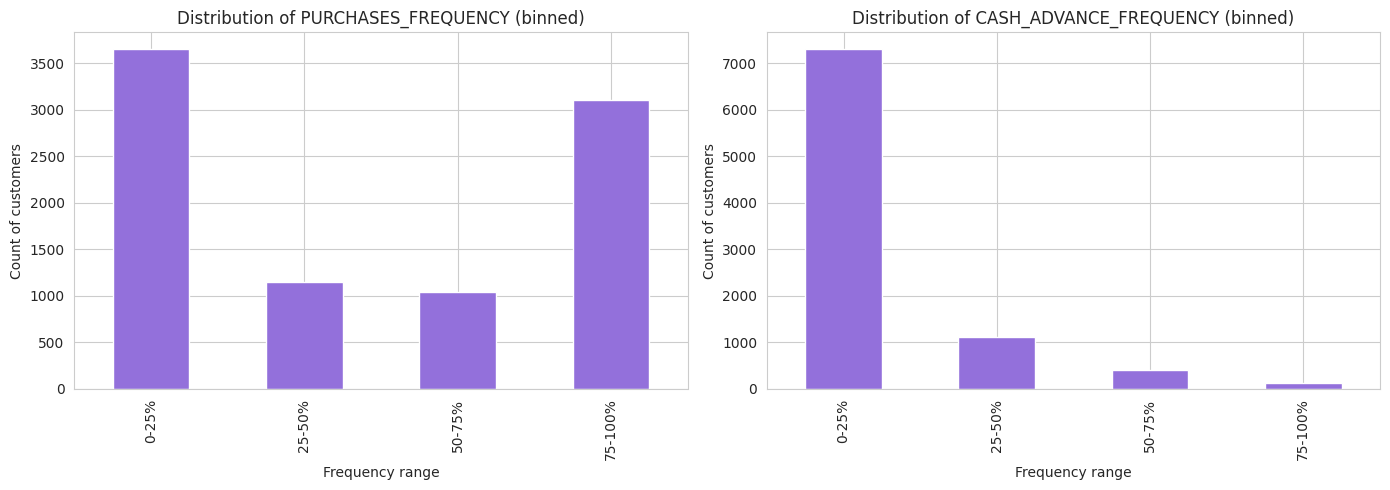

In [20]:
# CUST_ID is a unique identifier, so instead we bin the frequency-based variables into
# categories and show their distribution with bar charts
freq_vars = [c for c in ['PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY'] if c in df.columns]

fig, axes = plt.subplots(1, len(freq_vars), figsize=(7*len(freq_vars), 5))
if len(freq_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, freq_vars):
    binned = pd.cut(df[col], bins=[-0.01, 0.25, 0.5, 0.75, 1.0],
                     labels=['0-25%', '25-50%', '50-75%', '75-100%'])
    binned.value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple')
    ax.set_title(f'Distribution of {col} (binned)')
    ax.set_xlabel('Frequency range')
    ax.set_ylabel('Count of customers')
plt.tight_layout()
plt.show()


Visualize the relationship between numerical variables: Create scatter plots to examine the correlation between pairs of numerical variables, such as BALANCE and PURCHASES.

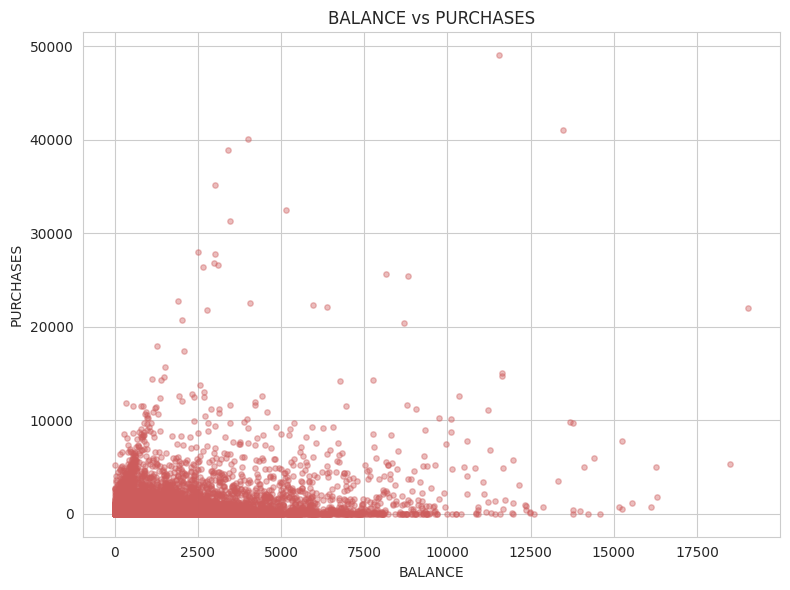

Correlation between BALANCE and PURCHASES: 0.181


In [21]:
# Scatter plot: BALANCE vs PURCHASES
plt.figure(figsize=(8, 6))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.4, s=15, color='indianred')
plt.title('BALANCE vs PURCHASES')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.tight_layout()
plt.show()

print(f"Correlation between BALANCE and PURCHASES: {df['BALANCE'].corr(df['PURCHASES']):.3f}")


Visualize the relationship between categorical and numerical variables: Create box plots or violin plots to compare the distribution of a numerical variable across different categories of a categorical variable (e.g., compare the distribution of PURCHASES for different CUST_ID categories).

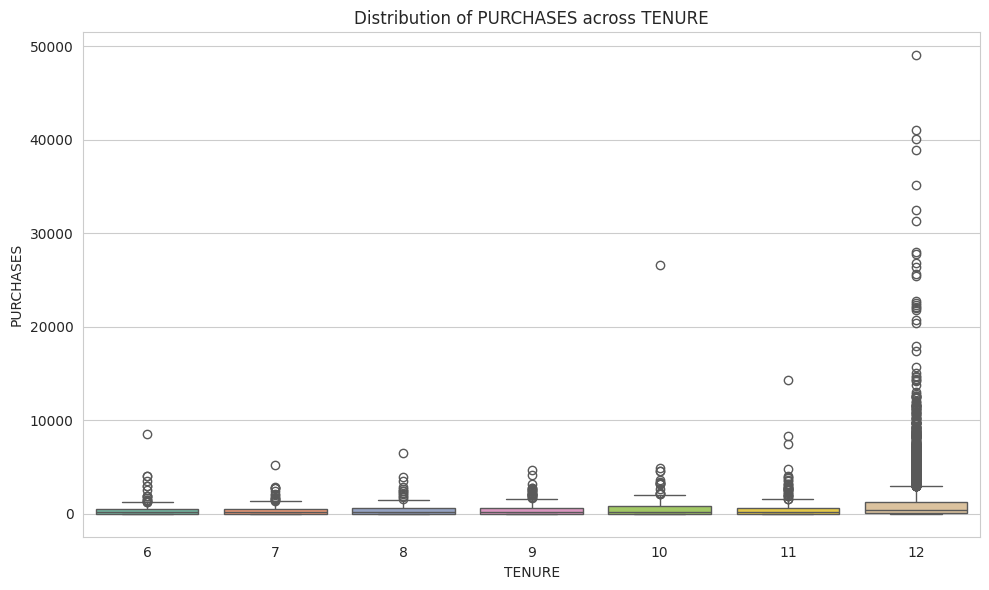

In [22]:
# Box plot: distribution of PURCHASES across TENURE categories
if 'TENURE' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='TENURE', y='PURCHASES', data=df, palette='Set2')
    plt.title('Distribution of PURCHASES across TENURE')
    plt.tight_layout()
    plt.show()
else:
    print("TENURE column not found.")


Visualize the relationship between multiple variables: Create pair plots or correlation matrices to explore the relationships between multiple variables simultaneously.

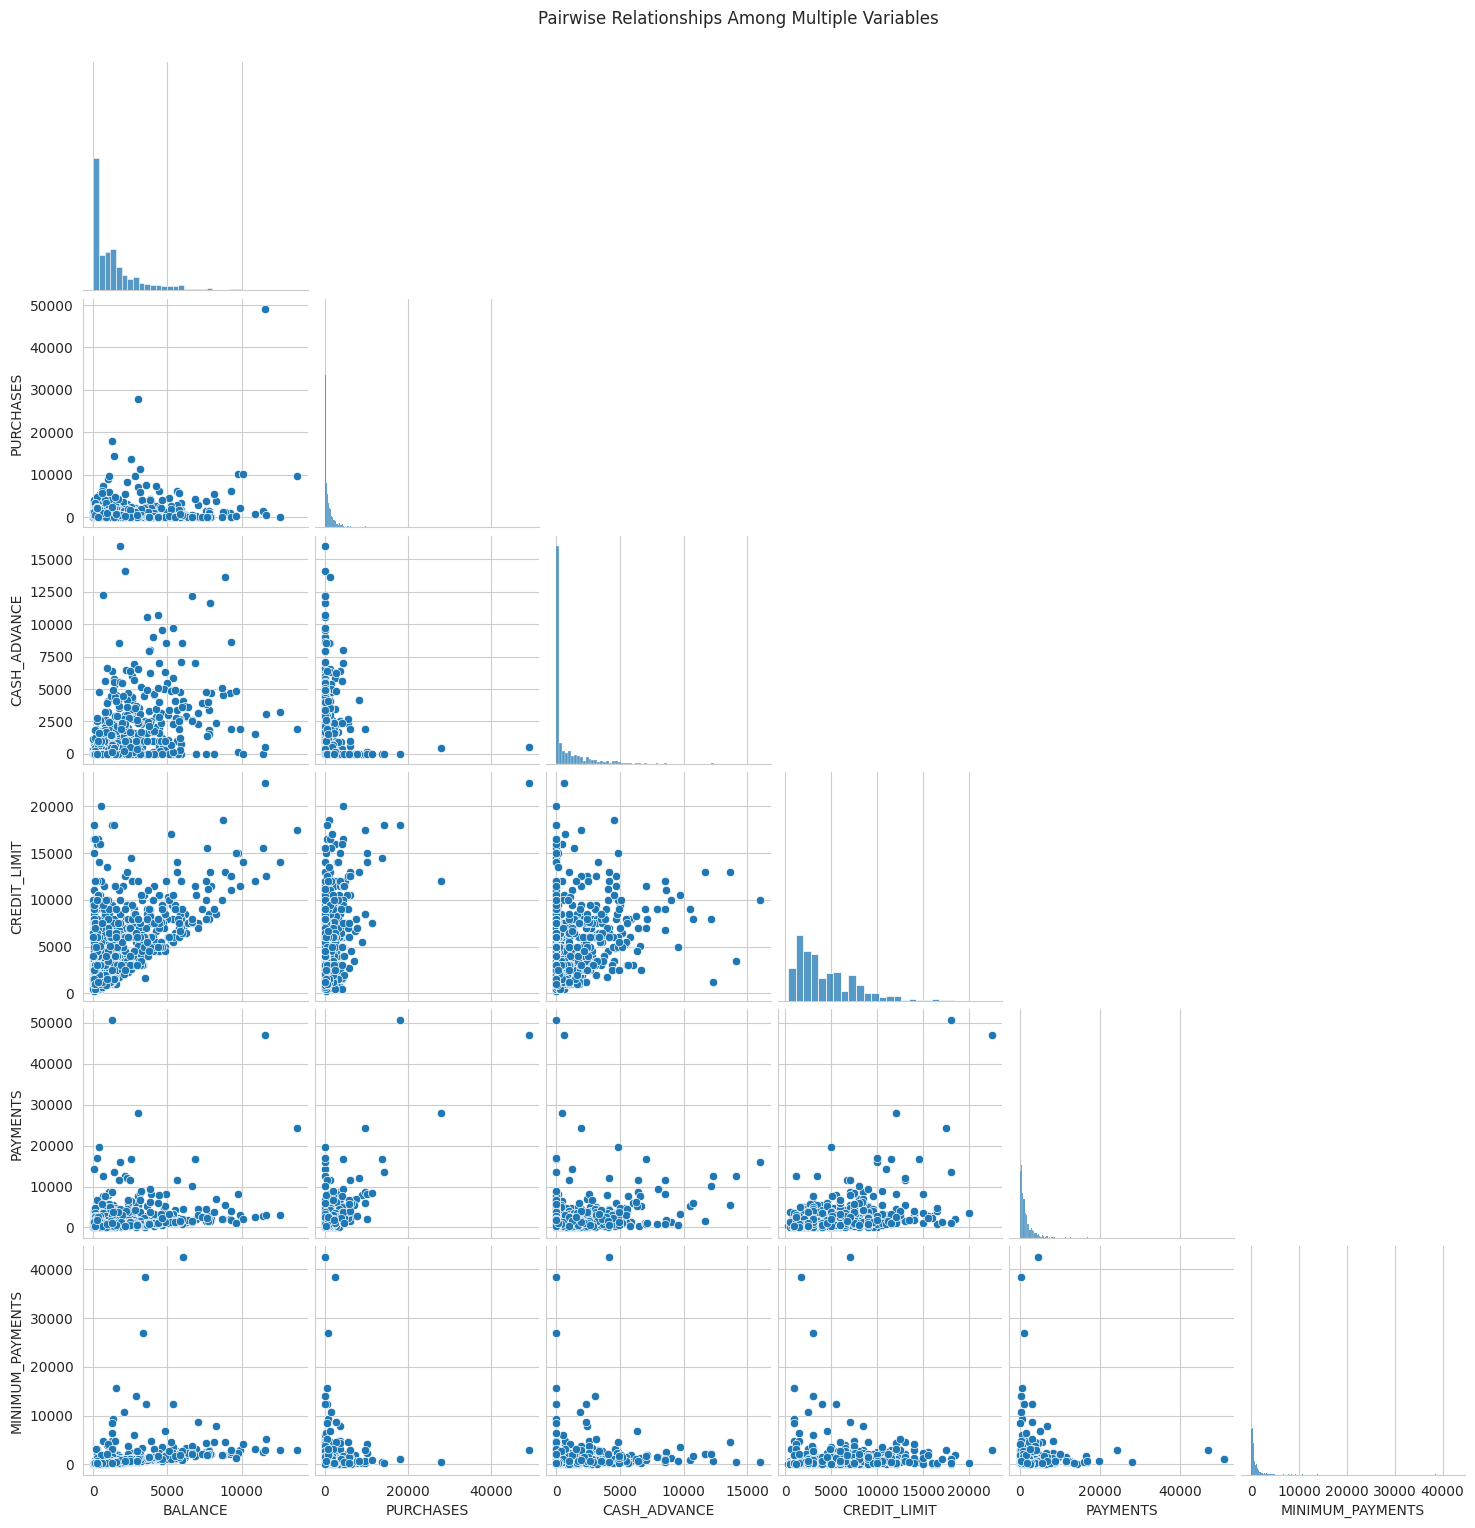

In [23]:
# Pair plot / correlation matrix across multiple key variables simultaneously
multi_vars = [c for c in ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                           'PAYMENTS', 'MINIMUM_PAYMENTS'] if c in df.columns]

sns.pairplot(df[multi_vars].sample(min(1000, len(df)), random_state=42), corner=True)
plt.suptitle('Pairwise Relationships Among Multiple Variables', y=1.02)
plt.show()


Visualize interactions between variables: Create interaction plots to examine how the relationship between two variables changes depending on the value of a third variable.

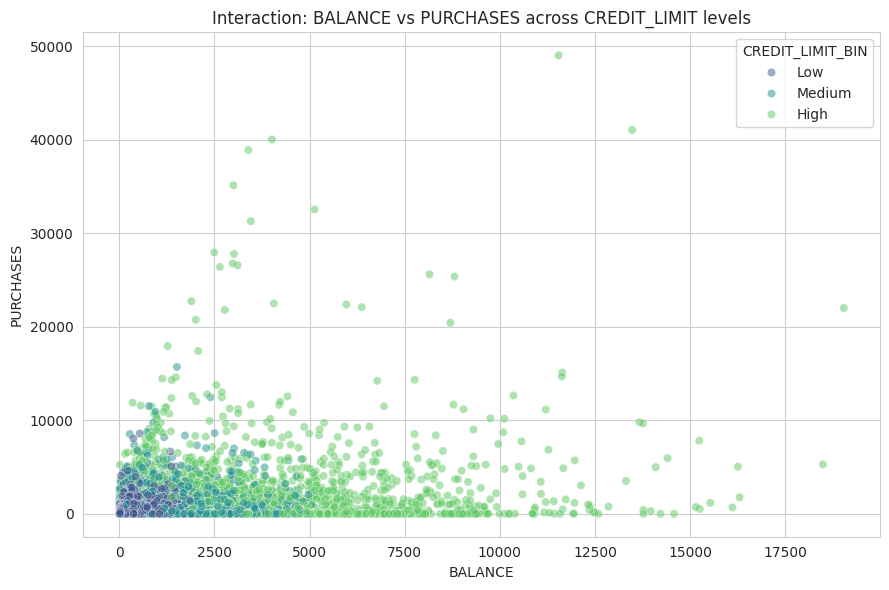

In [24]:
# Interaction plot: how BALANCE vs PURCHASES relationship changes across CREDIT_LIMIT bins
if 'CREDIT_LIMIT' in df.columns:
    df['CREDIT_LIMIT_BIN'] = pd.qcut(df['CREDIT_LIMIT'], q=3, labels=['Low', 'Medium', 'High'])

    plt.figure(figsize=(9, 6))
    sns.scatterplot(x='BALANCE', y='PURCHASES', hue='CREDIT_LIMIT_BIN', data=df, alpha=0.5, palette='viridis')
    plt.title('Interaction: BALANCE vs PURCHASES across CREDIT_LIMIT levels')
    plt.tight_layout()
    plt.show()
else:
    print("CREDIT_LIMIT column not found.")


Visualize trends over time: Create line charts to plot numerical variables against time (if applicable), such as the evolution of BALANCE or PURCHASES over the last 6 months.

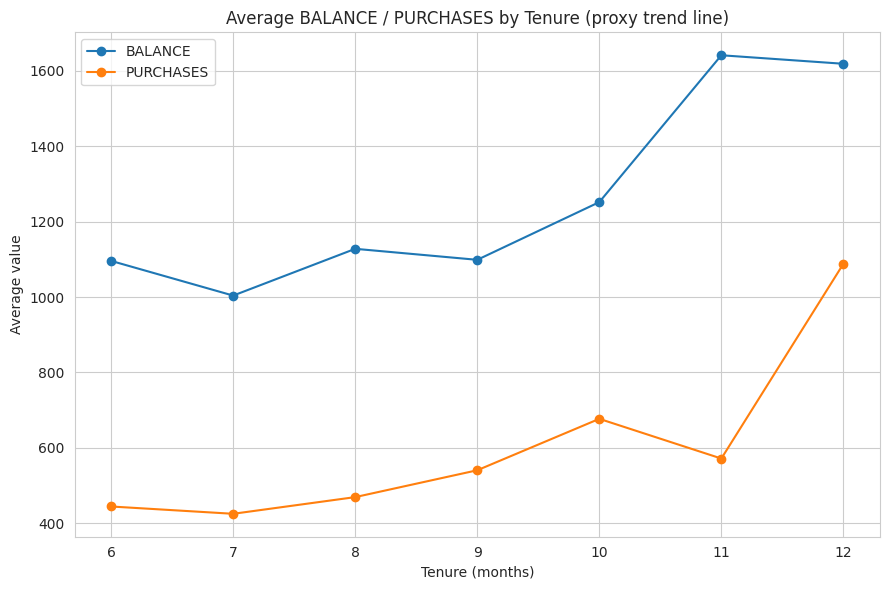

In [25]:
# This dataset has no explicit date/timestamp column, so a true time-series trend line
# is not available. As the closest available "time" axis we again use TENURE (months the
# account has existed) to approximate an evolution trend.
if 'TENURE' in df.columns:
    trend_vars = [c for c in ['BALANCE', 'PURCHASES'] if c in df.columns]
    trend = df.groupby('TENURE')[trend_vars].mean().sort_index()

    plt.figure(figsize=(9, 6))
    for col in trend_vars:
        plt.plot(trend.index, trend[col], marker='o', label=col)
    plt.title('Average BALANCE / PURCHASES by Tenure (proxy trend line)')
    plt.xlabel('Tenure (months)')
    plt.ylabel('Average value')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("TENURE column not found.")


Visualize seasonal patterns: Create seasonal decomposition plots to identify seasonal trends, cyclical patterns, and residuals in time-based data.

In [26]:
# Seasonal decomposition requires a true, regularly-spaced time series (e.g. monthly balances
# over several years). This dataset is a single cross-sectional snapshot per customer and has
# no repeated time index, so classical seasonal decomposition (trend/seasonal/residual) is not
# applicable here. If monthly time-series data per customer were available, we would use:
#
# from statsmodels.tsa.seasonal import seasonal_decompose
# result = seasonal_decompose(time_series, model='additive', period=12)
# result.plot()
#
# For this dataset we skip this step and note the limitation instead.
print("Seasonal decomposition skipped: dataset has no time-series / date column.")


Seasonal decomposition skipped: dataset has no time-series / date column.


Visualize the distribution of credit limits: Create a histogram or box plot to understand the distribution of credit limits among customers. Are there any significant differences in credit limits between different customer segments?

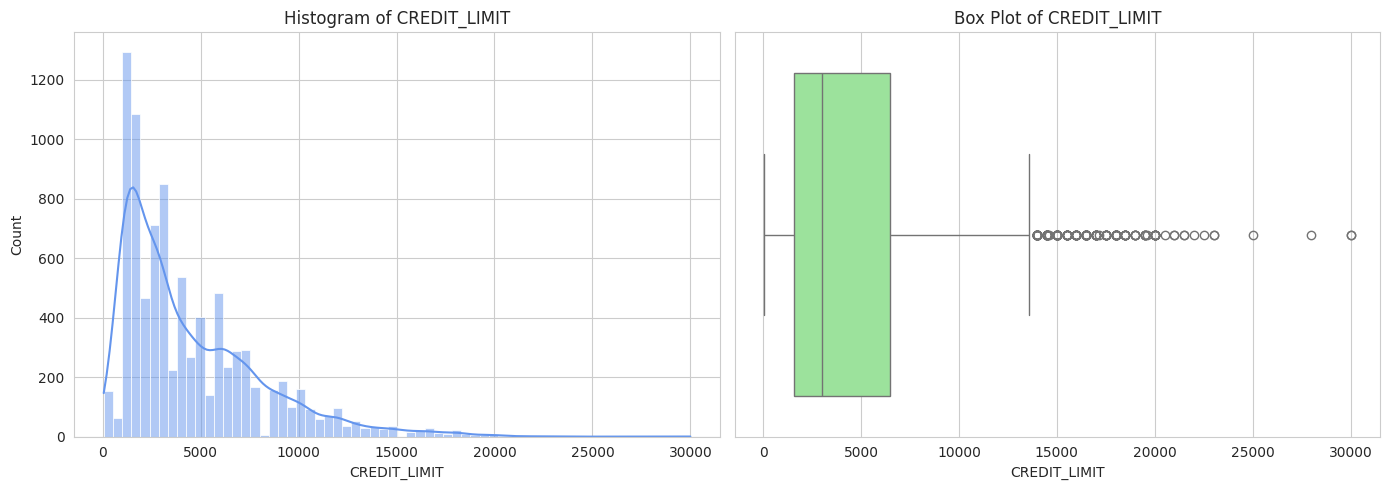

count     8950.000000
mean      4494.282473
std       3638.646702
min         50.000000
25%       1600.000000
50%       3000.000000
75%       6500.000000
max      30000.000000
Name: CREDIT_LIMIT, dtype: float64


In [27]:
# Distribution of credit limits
if 'CREDIT_LIMIT' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df['CREDIT_LIMIT'], kde=True, ax=axes[0], color='cornflowerblue')
    axes[0].set_title('Histogram of CREDIT_LIMIT')

    sns.boxplot(x=df['CREDIT_LIMIT'], ax=axes[1], color='lightgreen')
    axes[1].set_title('Box Plot of CREDIT_LIMIT')
    plt.tight_layout()
    plt.show()

    print(df['CREDIT_LIMIT'].describe())
else:
    print("CREDIT_LIMIT column not found.")


Visualize the relationship between payment patterns and delinquency: Create a scatter plot to examine the relationship between the percentage of full payments made (PRCFULLPAYMENT) and the number of times the minimum payment was not made (MINIMUM_PAYMENTS). Are there any patterns indicating which customers are more likely to be delinquent?

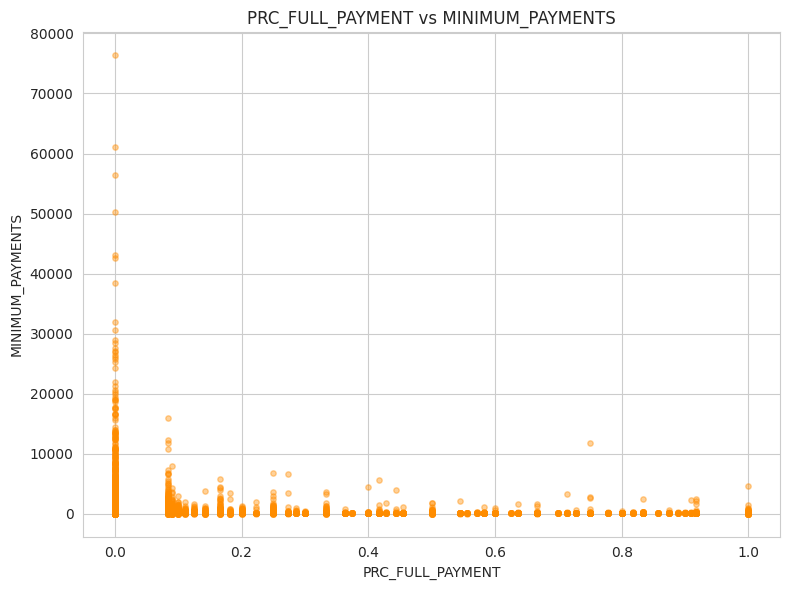

Correlation: -0.135
Customers with a low percentage of full payments and high minimum-payment amounts are the most likely candidates for delinquency risk.


In [28]:
# Relationship between PRC_FULL_PAYMENT and MINIMUM_PAYMENTS
pay_col = next((c for c in df.columns if 'PRC_FULL_PAYMENT' in c.upper() or 'PRCFULLPAYMENT' in c.upper()), None)
min_pay_col = next((c for c in df.columns if 'MINIMUM_PAYMENT' in c.upper()), None)

if pay_col and min_pay_col:
    plt.figure(figsize=(8, 6))
    plt.scatter(df[pay_col], df[min_pay_col], alpha=0.4, s=15, color='darkorange')
    plt.title(f'{pay_col} vs {min_pay_col}')
    plt.xlabel(pay_col)
    plt.ylabel(min_pay_col)
    plt.tight_layout()
    plt.show()
    print(f"Correlation: {df[pay_col].corr(df[min_pay_col]):.3f}")
    print("Customers with a low percentage of full payments and high minimum-payment amounts "
          "are the most likely candidates for delinquency risk.")
else:
    print("Required columns not found.")


Visualize the distribution of tenure: Create a histogram or bar chart to understand the distribution of credit card tenure among customers. Are there any significant differences in tenure between different customer segments?

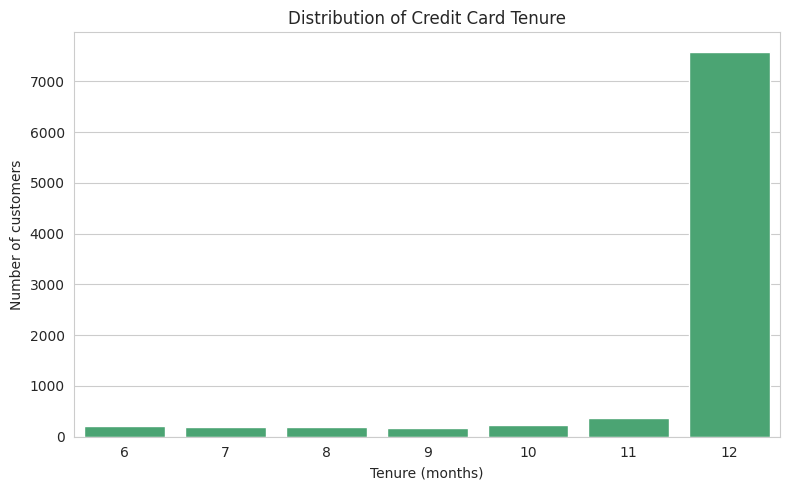

In [29]:
# Distribution of tenure
if 'TENURE' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='TENURE', data=df, color='mediumseagreen', order=sorted(df['TENURE'].unique()))
    plt.title('Distribution of Credit Card Tenure')
    plt.xlabel('Tenure (months)')
    plt.ylabel('Number of customers')
    plt.tight_layout()
    plt.show()
else:
    print("TENURE column not found.")


Visualize the relationship between purchase frequency and purchase amount: Create a scatter plot to examine the relationship between the frequency of purchases (PURCHASES_FREQUENCY) and the total purchase amount (PURCHASES). Are there any patterns indicating which customers are more likely to make larger purchases?

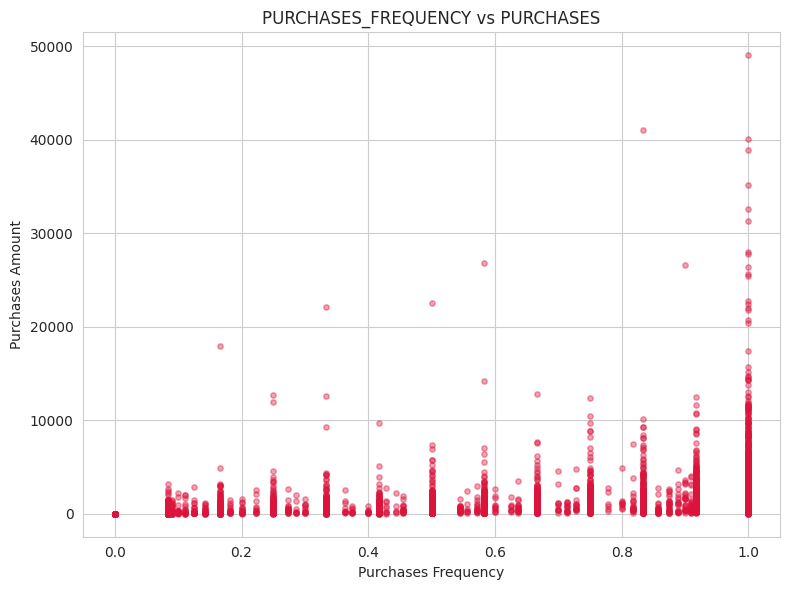

Correlation: 0.393


In [30]:
# Relationship between purchase frequency and purchase amount
plt.figure(figsize=(8, 6))
plt.scatter(df['PURCHASES_FREQUENCY'], df['PURCHASES'], alpha=0.4, s=15, color='crimson')
plt.title('PURCHASES_FREQUENCY vs PURCHASES')
plt.xlabel('Purchases Frequency')
plt.ylabel('Purchases Amount')
plt.tight_layout()
plt.show()
print(f"Correlation: {df['PURCHASES_FREQUENCY'].corr(df['PURCHASES']):.3f}")


Visualize the relationship between cash advance usage and purchase behavior: Create a scatter plot to examine the relationship between the amount of cash advances (CASH_ADVANCE) and the total purchase amount (PURCHASES). Are there any patterns indicating which customers are more likely to use cash advances and how this affects their purchase behavior?

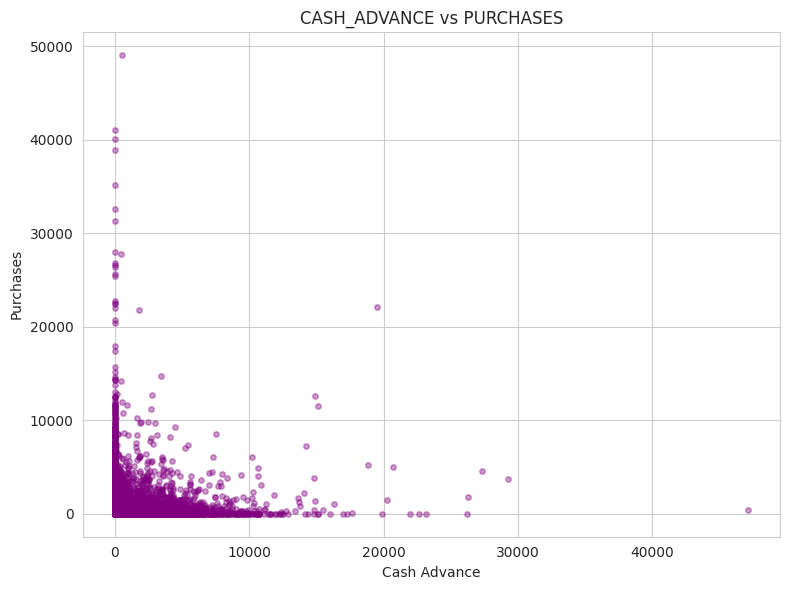

Correlation: -0.051
A negative/weak relationship typically suggests customers who rely heavily on cash advances tend to make fewer direct purchases with their card.


In [31]:
# Relationship between cash advance usage and purchase behavior
plt.figure(figsize=(8, 6))
plt.scatter(df['CASH_ADVANCE'], df['PURCHASES'], alpha=0.4, s=15, color='purple')
plt.title('CASH_ADVANCE vs PURCHASES')
plt.xlabel('Cash Advance')
plt.ylabel('Purchases')
plt.tight_layout()
plt.show()
print(f"Correlation: {df['CASH_ADVANCE'].corr(df['PURCHASES']):.3f}")
print("A negative/weak relationship typically suggests customers who rely heavily on cash "
      "advances tend to make fewer direct purchases with their card.")


## Data Preprocessing

Scale numerical variables to a common range (e.g., 0-1 or -1 to 1) using techniques like min-max scaling or standardization to improve model performance and prevent numerical instability.

In [32]:
# Scale numerical variables using standardization (mean=0, std=1)
model_features = [c for c in numeric_cols if c not in ['CREDIT_LIMIT_BIN']]
model_features = [c for c in model_features if df[c].nunique() > 1]

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df[model_features])
df_scaled = pd.DataFrame(scaled_array, columns=model_features, index=df.index)

df_scaled.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


Convert categorical variables to numerical representations using techniques like one-hot encoding or label encoding, depending on the nature of the variables.

In [33]:
# Convert categorical variables to numerical representations
# CUST_ID is a unique identifier (not a predictive feature) and is excluded from modeling
# rather than encoded. If there were true categorical features (e.g. a card-type column),
# we would one-hot encode them like this:
#
# df_encoded = pd.get_dummies(df, columns=['CARD_TYPE'], drop_first=True)

print("id_cols excluded from modeling features:", id_cols)
print("No additional categorical variables require encoding in this dataset.")


id_cols excluded from modeling features: ['CUST_ID']
No additional categorical variables require encoding in this dataset.


## Feature Engineering

Combine existing features to capture interactions between them (e.g., multiply BALANCE and PURCHASES_FREQUENCY to create a new feature representing the total spending per unit time).

In [34]:
# Feature engineering: combine existing features to capture interactions
if 'BALANCE' in df.columns and 'PURCHASES_FREQUENCY' in df.columns:
    df['SPEND_PER_FREQ'] = df['BALANCE'] * df['PURCHASES_FREQUENCY']

print(df[['BALANCE', 'PURCHASES_FREQUENCY', 'SPEND_PER_FREQ']].head())


       BALANCE  PURCHASES_FREQUENCY  SPEND_PER_FREQ
0    40.900749             0.166667        6.816805
1  3202.467416             0.000000        0.000000
2  2495.148862             1.000000     2495.148862
3  1666.670542             0.083333      138.888656
4   817.714335             0.083333       68.142589


Derive new features by calculating ratios or percentages between existing features (e.g., calculate the percentage of credit limit used by dividing BALANCE by CREDIT_LIMIT).

In [35]:
# Derive ratio/percentage features
if 'BALANCE' in df.columns and 'CREDIT_LIMIT' in df.columns:
    df['CREDIT_UTILIZATION'] = df['BALANCE'] / df['CREDIT_LIMIT'].replace(0, np.nan)
    df['CREDIT_UTILIZATION'].fillna(0, inplace=True)

if 'ONEOFF_PURCHASES' in df.columns and 'PURCHASES' in df.columns:
    df['ONEOFF_PURCHASE_RATIO'] = df['ONEOFF_PURCHASES'] / df['PURCHASES'].replace(0, np.nan)
    df['ONEOFF_PURCHASE_RATIO'].fillna(0, inplace=True)

print(df[[c for c in ['CREDIT_UTILIZATION', 'ONEOFF_PURCHASE_RATIO'] if c in df.columns]].describe())


       CREDIT_UTILIZATION  ONEOFF_PURCHASE_RATIO
count         8950.000000            8950.000000
mean             0.388884               0.379718
std              0.389722               0.426036
min              0.000000               0.000000
25%              0.041494               0.000000
50%              0.302720               0.111363
75%              0.717571               0.874174
max             15.909951               1.803692


Extract time-based features from dates or timestamps (e.g., create features for day of week, month, or year).

In [36]:
# This dataset does not contain date/timestamp columns (it's a single snapshot per customer),
# so classic time-based features (day of week, month, year) cannot be extracted.
# TENURE (months the account has been active) is the only time-related feature available,
# and it is already present in the dataset.
print("No date/timestamp columns available; TENURE is the only time-related feature present.")


No date/timestamp columns available; TENURE is the only time-related feature present.


Create new features by grouping data and calculating summary statistics within each group (e.g., calculate the average purchase amount for each customer segment).

In [37]:
# Group data and calculate summary statistics within each group (by TENURE)
if 'TENURE' in df.columns:
    group_stats = df.groupby('TENURE')[['PURCHASES', 'BALANCE']].agg(['mean', 'std', 'count'])
    print(group_stats)
else:
    print("TENURE column not found.")


          PURCHASES                         BALANCE                   
               mean          std count         mean          std count
TENURE                                                                
6        443.941667   874.513851   204  1095.890702  1723.109400   204
7        424.559421   682.754918   190  1003.800362  1268.620838   190
8        468.858929   778.851547   196  1127.963470  1723.933049   196
9        540.138171   822.492131   175  1098.752149  1515.354663   175
10       676.631271  1899.686770   236  1251.955773  1638.359492   236
11       571.222411  1191.731621   365  1641.770893  1987.618967   365
12      1088.192402  2257.365708  7584  1619.158166  2135.816393  7584


Leverage domain knowledge to create new features that are relevant to the problem at hand (e.g., create a feature indicating whether a customer has made a purchase in the last 30 days).

In [38]:
# Domain-knowledge feature: flag customers who behave like "revolvers" (carry balance,
# rely on cash advances) vs "transactors" (pay off in full, mostly use purchases)
if 'PRC_FULL_PAYMENT' in df.columns or pay_col:
    full_pay_col = pay_col if 'pay_col' in dir() and pay_col else 'PRC_FULL_PAYMENT'
    df['IS_REVOLVER'] = ((df[full_pay_col] < 0.2) & (df['CASH_ADVANCE'] > 0)).astype(int)
    print(df['IS_REVOLVER'].value_counts())
else:
    print("Required column for full payment percentage not found.")


IS_REVOLVER
0    4964
1    3986
Name: count, dtype: int64


Create polynomial features by raising existing numerical features to powers (e.g., create features for BALANCE^2 and PURCHASES^2).

In [39]:
# Polynomial features
if 'BALANCE' in df.columns:
    df['BALANCE_SQ'] = df['BALANCE'] ** 2
if 'PURCHASES' in df.columns:
    df['PURCHASES_SQ'] = df['PURCHASES'] ** 2

print(df[[c for c in ['BALANCE_SQ', 'PURCHASES_SQ'] if c in df.columns]].describe())


         BALANCE_SQ  PURCHASES_SQ
count  8.950000e+03  8.950000e+03
mean   6.779872e+06  5.571118e+06
std    1.894674e+07  5.194866e+07
min    0.000000e+00  0.000000e+00
25%    1.645625e+04  1.570942e+03
50%    7.628018e+05  1.305233e+05
75%    4.219491e+06  1.232389e+06
max    3.626411e+08  2.404879e+09


Calculate the difference between time-based features (e.g., calculate the difference between the last purchase date and the last payment date).

In [40]:
# This dataset has no last-purchase-date or last-payment-date columns (it's an aggregated
# snapshot, not transaction-level data), so a literal "difference between dates" feature
# cannot be computed here. This step is skipped for that reason.
print("No date columns available to compute a time-difference feature; step skipped.")


No date columns available to compute a time-difference feature; step skipped.


Group data by specific criteria and calculate custom aggregations (e.g., calculate the median purchase amount for each customer segment).

In [41]:
# Group by TENURE and calculate the median purchase amount for each segment
if 'TENURE' in df.columns:
    median_purchases_by_tenure = df.groupby('TENURE')['PURCHASES'].median().sort_index()
    print(median_purchases_by_tenure)
else:
    print("TENURE column not found.")


TENURE
6     175.325
7     178.415
8     176.005
9     230.220
10    208.125
11    202.300
12    403.200
Name: PURCHASES, dtype: float64


Use feature selection techniques (e.g., correlation analysis, recursive feature elimination) to identify the most important features and remove redundant or irrelevant ones.

In [42]:
# Feature selection using correlation analysis - drop highly correlated (redundant) features
corr = df[model_features].corr().abs()
upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.9)]
print("Highly correlated (redundant) features to consider dropping (corr > 0.9):", to_drop)

final_features = [c for c in model_features if c not in to_drop]
print(f"\nFinal feature count: {len(final_features)} (from {len(model_features)})")
print(final_features)


Highly correlated (redundant) features to consider dropping (corr > 0.9): ['ONEOFF_PURCHASES']

Final feature count: 16 (from 17)
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


## PCA

Standardize the numerical features to ensure they have a mean of 0 and a standard deviation of 1, as PCA is sensitive to the scale of the variables.

In [43]:
# Standardize features prior to PCA (mean 0, std 1)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(df[final_features])
print("Scaled data shape:", X_scaled.shape)
print("Mean (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Std (should be ~1):", np.round(X_scaled.std(axis=0)[:5], 3))


Scaled data shape: (8950, 16)
Mean (should be ~0): [-0.  0.  0.  0. -0.]
Std (should be ~1): [1. 1. 1. 1. 1.]


Compute the covariance matrix of the standardized data to measure the relationships between the variables.

In [44]:
# Compute the covariance matrix of the standardized data
cov_matrix = np.cov(X_scaled, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)
pd.DataFrame(cov_matrix, index=final_features, columns=final_features).round(2)


Covariance matrix shape: (16, 16)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.00,0.32,0.18,0.13,0.50,-0.08,0.07,-0.06,0.45,0.39,0.15,0.53,0.32,0.40,-0.32,0.07
BALANCE_FREQUENCY,0.32,1.00,0.13,0.12,0.10,0.23,0.20,0.18,0.19,0.14,0.19,0.10,0.07,0.13,-0.10,0.12
PURCHASES,0.18,0.13,1.00,0.68,-0.05,0.39,0.50,0.32,-0.12,-0.07,0.69,0.36,0.60,0.10,0.18,0.09
INSTALLMENTS_PURCHASES,0.13,0.12,0.68,1.00,-0.06,0.44,0.21,0.51,-0.13,-0.07,0.63,0.26,0.38,0.13,0.18,0.09
CASH_ADVANCE,0.50,0.10,-0.05,-0.06,1.00,-0.22,-0.09,-0.18,0.63,0.66,-0.08,0.30,0.45,0.14,-0.15,-0.07
PURCHASES_FREQUENCY,-0.08,0.23,0.39,0.44,-0.22,1.00,0.50,0.86,-0.31,-0.20,0.57,0.12,0.10,0.01,0.31,0.06
ONEOFF_PURCHASES_FREQUENCY,0.07,0.20,0.50,0.21,-0.09,0.50,1.00,0.14,-0.11,-0.07,0.54,0.30,0.24,-0.03,0.16,0.08
PURCHASES_INSTALLMENTS_FREQUENCY,-0.06,0.18,0.32,0.51,-0.18,0.86,0.14,1.00,-0.26,-0.17,0.53,0.06,0.09,0.03,0.25,0.07
CASH_ADVANCE_FREQUENCY,0.45,0.19,-0.12,-0.13,0.63,-0.31,-0.11,-0.26,1.00,0.80,-0.13,0.13,0.18,0.10,-0.25,-0.13
CASH_ADVANCE_TRX,0.39,0.14,-0.07,-0.07,0.66,-0.20,-0.07,-0.17,0.80,1.00,-0.07,0.15,0.26,0.11,-0.17,-0.04


Decompose the covariance matrix into its eigenvectors and eigenvalues, which represent the principal components and their corresponding variances.

In [45]:
# Eigen-decomposition of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in descending order of eigenvalue
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("Eigenvalues (descending):")
print(np.round(eigenvalues, 3))


Eigenvalues (descending):
[4.162 3.436 1.328 1.246 1.034 0.925 0.811 0.712 0.646 0.51  0.305 0.272
 0.243 0.176 0.152 0.045]


Choose the principal components with the highest eigenvalues, as these components explain the most variance in the data. The number of components to keep can be determined based on the desired level of dimensionality reduction or by analyzing the scree plot (a plot of the eigenvalues in descending order).

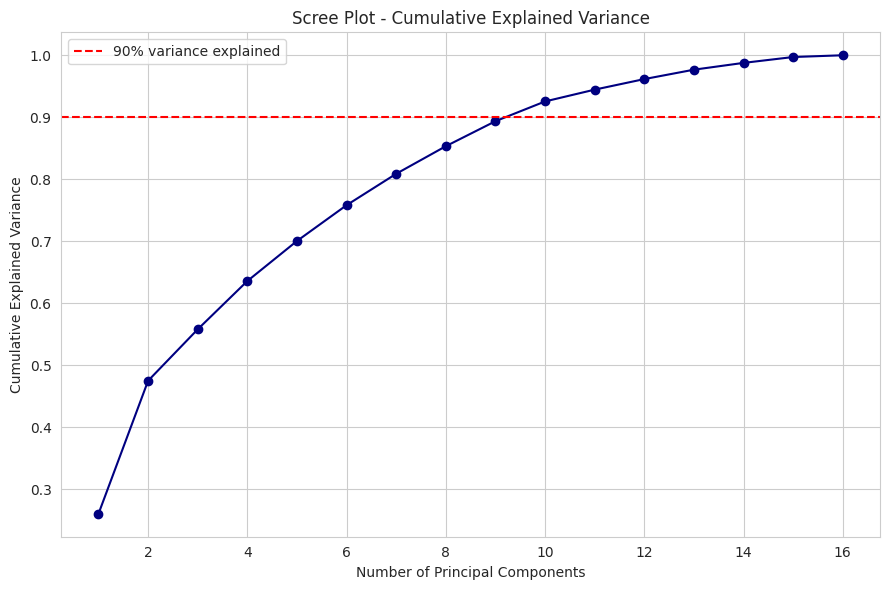

Number of components needed to explain >=90% of variance: 10


In [46]:
# Scree plot to decide how many principal components to keep
explained_var_ratio = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var_ratio)

plt.figure(figsize=(9, 6))
plt.plot(range(1, len(eigenvalues)+1), cumulative_var, marker='o', color='navy')
plt.axhline(y=0.9, color='red', linestyle='--', label='90% variance explained')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot - Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_components = np.argmax(cumulative_var >= 0.90) + 1
print(f"Number of components needed to explain >=90% of variance: {n_components}")


Project the original data onto the selected principal components to obtain the reduced-dimensional representation. The resulting features are the principal components, which are uncorrelated and capture the most important information in the data.

In [47]:
# Project the original data onto the selected principal components using sklearn PCA
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Reduced data shape:", X_pca.shape)
print("Explained variance ratio per component:", np.round(pca.explained_variance_ratio_, 3))
print("Total variance explained:", np.round(pca.explained_variance_ratio_.sum(), 3))

pca_cols = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=df.index)
df_pca.head()


Reduced data shape: (8950, 10)
Explained variance ratio per component: [0.26  0.215 0.083 0.078 0.065 0.058 0.051 0.044 0.04  0.032]
Total variance explained: 0.925


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-1.586084,-1.245518,0.096850,0.669642,-0.057621,0.103056,-0.822247,0.151324,0.129915,0.166564
1,-1.308420,2.400806,-0.859517,0.484552,-0.045806,0.923795,0.591861,-0.014302,0.665256,0.912241
2,0.987951,-0.290831,0.617202,0.949384,2.356219,-1.149393,1.001166,-0.080266,-0.851824,0.248095
3,-1.202629,-0.182572,-0.603310,1.517524,0.070103,-0.115568,0.067766,-0.721961,-0.085233,-0.618800
4,-1.540112,-0.850213,0.428562,0.825774,0.400618,-0.092378,-0.731143,0.451299,0.601336,0.304783


## DBSCAN

Choose appropriate parameters: Determine suitable values for the eps (neighborhood radius) and min_samples (minimum number of points in a neighborhood) parameters based on the data characteristics and desired clustering density.

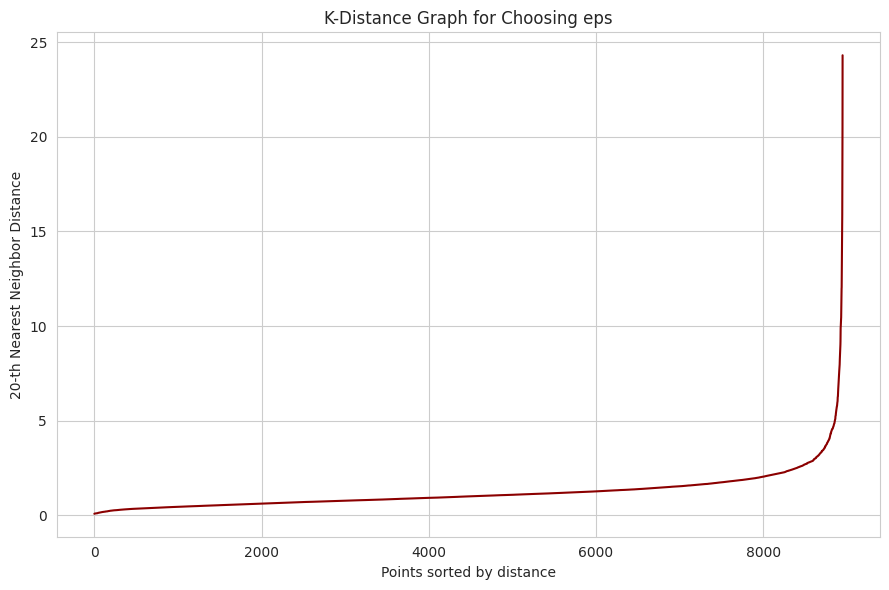

Suggested min_samples: 20
Suggested eps (90th percentile of k-distances): 2.088


In [48]:
# Choose appropriate eps and min_samples for DBSCAN using the k-distance graph
from sklearn.neighbors import NearestNeighbors

min_samples = 2 * X_pca.shape[1]  # common rule of thumb: min_samples >= 2 * dimensions

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 6))
plt.plot(k_distances, color='darkred')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.title('K-Distance Graph for Choosing eps')
plt.tight_layout()
plt.show()

# eps is chosen at the "elbow" of this curve - inspect the plot and set accordingly.
# As a reasonable automatic estimate, take the 90th percentile of these distances.
eps_value = np.percentile(k_distances, 90)
print(f"Suggested min_samples: {min_samples}")
print(f"Suggested eps (90th percentile of k-distances): {eps_value:.3f}")


Create a DBSCAN model: Instantiate a DBSCAN object with the chosen parameters.

In [49]:
# Create a DBSCAN model with the chosen parameters
dbscan_model = DBSCAN(eps=eps_value, min_samples=min_samples)
print(dbscan_model)


DBSCAN(eps=np.float64(2.087907496799275), min_samples=20)


Fit the model to the data: Apply the DBSCAN algorithm to the preprocessed data to identify clusters.

In [50]:
# Fit DBSCAN to the PCA-reduced data
dbscan_model.fit(X_pca)


DBSCAN(eps=np.float64(2.087907496799275), min_samples=20)

Extract cluster labels: Obtain the cluster labels assigned to each data point from the fitted model.

In [51]:
# Extract cluster labels (-1 indicates noise/outlier points)
dbscan_labels = dbscan_model.labels_
df_pca['DBSCAN_Cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print("\nCluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())


Number of clusters found: 1
Number of noise points: 423 (4.7%)

Cluster distribution:
-1     423
 0    8527
Name: count, dtype: int64


Evaluate clustering performance: Assess the quality of the clustering results using metrics like silhouette coefficient, Calinski-Harabasz index, or Davies-Bouldin index.

In [52]:
# Evaluate DBSCAN clustering performance
# Metrics require at least 2 clusters and are computed excluding noise points
mask = dbscan_labels != -1

if n_clusters >= 2 and mask.sum() > 0:
    sil_score = silhouette_score(X_pca[mask], dbscan_labels[mask])
    ch_score = calinski_harabasz_score(X_pca[mask], dbscan_labels[mask])
    db_score = davies_bouldin_score(X_pca[mask], dbscan_labels[mask])

    print(f"Silhouette Score: {sil_score:.3f}")
    print(f"Calinski-Harabasz Index: {ch_score:.3f}")
    print(f"Davies-Bouldin Index: {db_score:.3f}")
else:
    print("Not enough clusters (excluding noise) to compute clustering metrics. "
          "Try adjusting eps / min_samples.")


Not enough clusters (excluding noise) to compute clustering metrics. Try adjusting eps / min_samples.


Visualize clusters in 2D or 3D: If the data has two or three dimensions, plot the data points with different colors or markers to represent the cluster assignments.

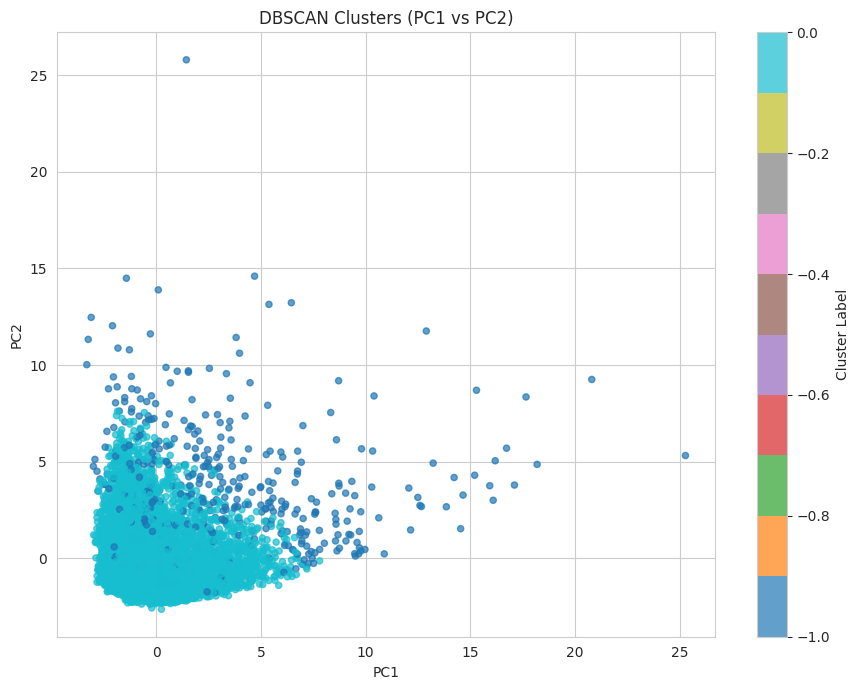

In [53]:
# Visualize DBSCAN clusters in 2D using the first two principal components
plt.figure(figsize=(9, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=dbscan_labels, cmap='tab10', s=20, alpha=0.7)
plt.title('DBSCAN Clusters (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster Label')
plt.tight_layout()
plt.show()



Visualize clusters in higher dimensions: Use techniques like t-SNE or UMAP to reduce the dimensionality of the data to 2D or 3D for visualization.

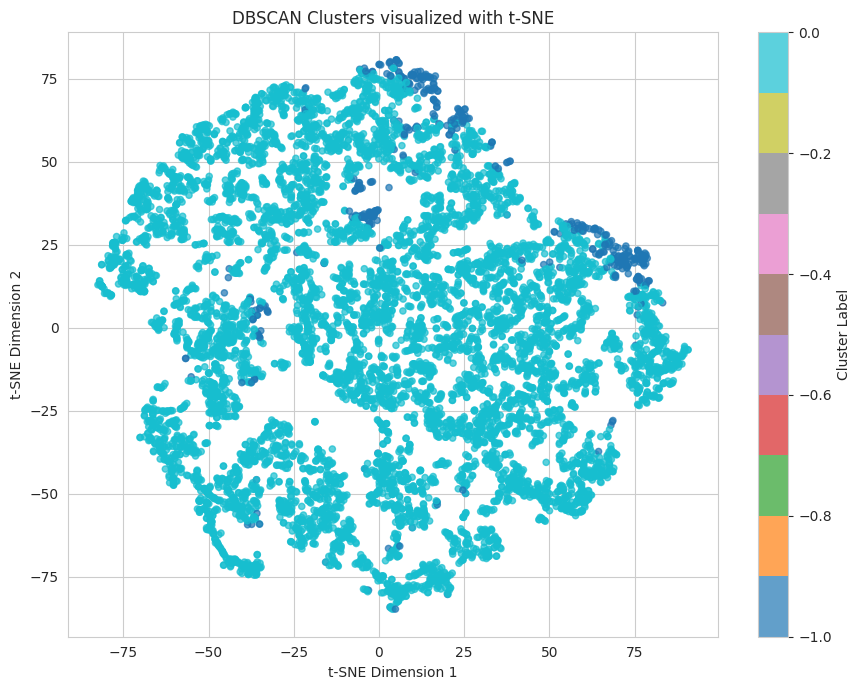

In [54]:
# Visualize clusters in higher dimensions using t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels, cmap='tab10', s=20, alpha=0.7)
plt.title('DBSCAN Clusters visualized with t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster Label')
plt.tight_layout()
plt.show()


Visualize cluster density: Create a density plot or heatmap to show the distribution of data points within each cluster and identify areas with high or low density.

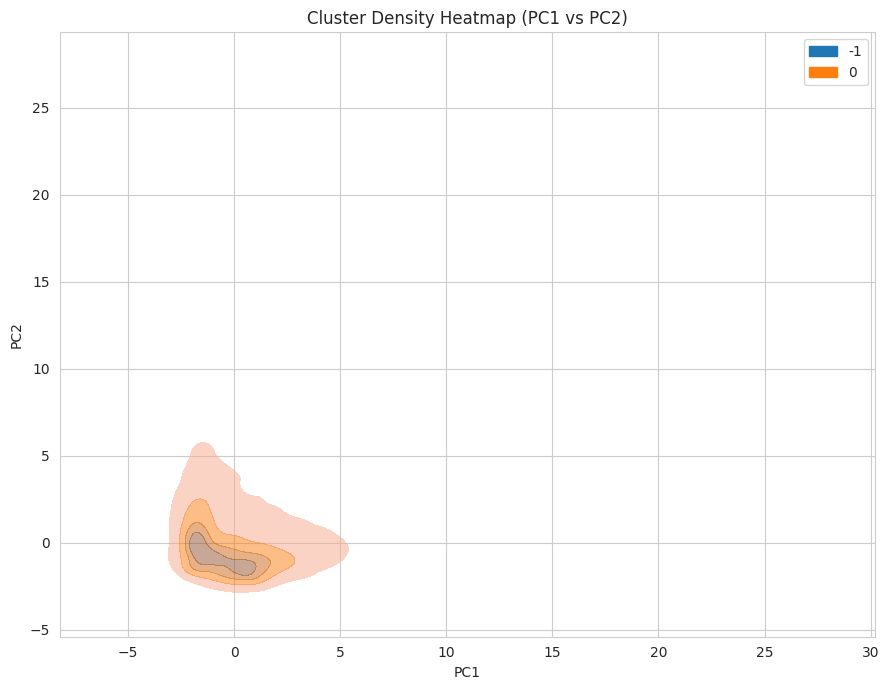

In [55]:
# Visualize cluster density using a 2D KDE / density heatmap
plt.figure(figsize=(9, 7))
sns.kdeplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=dbscan_labels, fill=True, alpha=0.5, palette='tab10', levels=5)
plt.title('Cluster Density Heatmap (PC1 vs PC2)')
plt.tight_layout()
plt.show()


Visualize outliers: Identify and visualize outliers as points that are not assigned to any cluster.

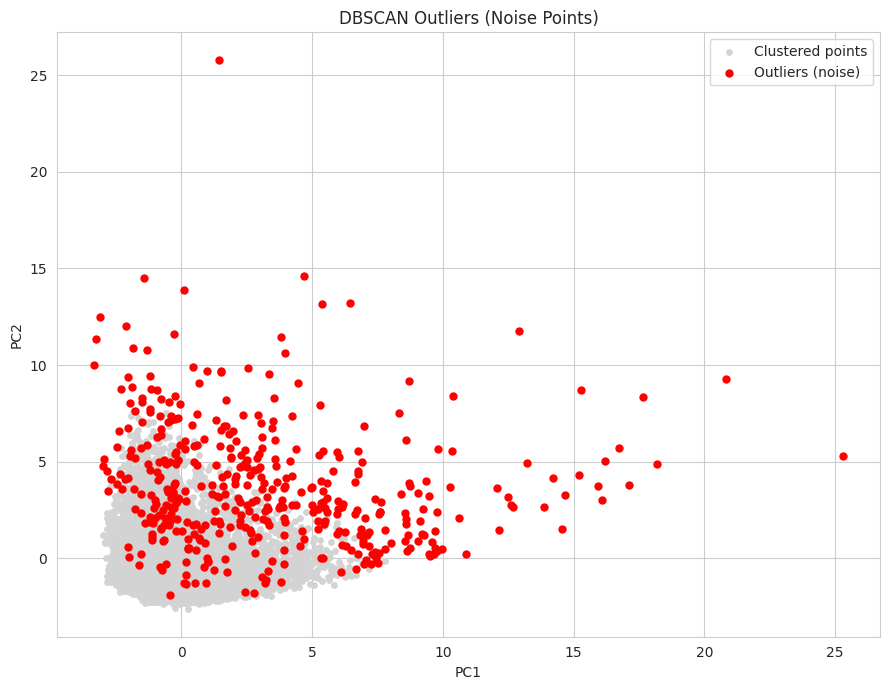

Total outliers detected: 423


In [56]:
# Visualize outliers (noise points, labeled -1 by DBSCAN)
plt.figure(figsize=(9, 7))
plt.scatter(df_pca.loc[dbscan_labels != -1, 'PC1'], df_pca.loc[dbscan_labels != -1, 'PC2'],
            c='lightgray', s=15, label='Clustered points')
plt.scatter(df_pca.loc[dbscan_labels == -1, 'PC1'], df_pca.loc[dbscan_labels == -1, 'PC2'],
            c='red', s=25, label='Outliers (noise)')
plt.title('DBSCAN Outliers (Noise Points)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total outliers detected: {n_noise}")


## Other Clustering Techniques

### Hierarchical Clustering:

Choose a linkage method: Select an appropriate linkage method (e.g., single, complete, average, centroid) based on the desired cluster properties.

In [57]:
# Hierarchical Clustering - choose linkage method (Ward minimizes within-cluster variance,
# and works well with Euclidean distance on continuous features like ours)
linkage_method = 'ward'
Z = linkage(X_pca, method=linkage_method)
print(f"Linkage method used: {linkage_method}")
print("Linkage matrix shape:", Z.shape)


Linkage method used: ward
Linkage matrix shape: (8949, 4)


Construct the dendrogram: Create a dendrogram to visualize the hierarchical structure of the clusters.

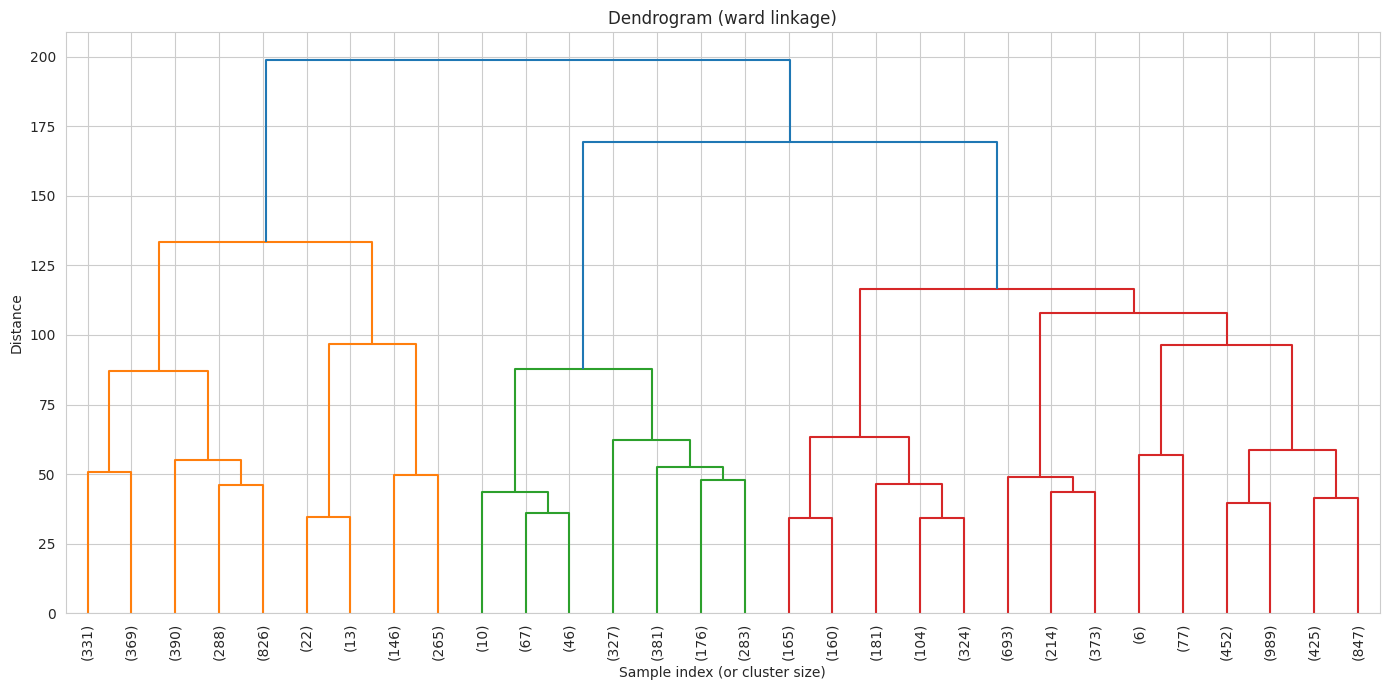

In [58]:
# Construct the dendrogram
plt.figure(figsize=(14, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title(f'Dendrogram ({linkage_method} linkage)')
plt.xlabel('Sample index (or cluster size)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


Determine the number of clusters: Decide on the number of clusters based on the dendrogram or using a cutoff value for the distance between clusters.

In [59]:
# Determine the number of clusters from the dendrogram using a distance cutoff
# Inspect the dendrogram above and pick a cutoff that crosses the tallest vertical lines
# without crossing too many merges. Here we choose k=4 as a reasonable starting point.
n_clusters_hc = 4
cutoff_distance = Z[-(n_clusters_hc - 1), 2]
print(f"Chosen number of clusters: {n_clusters_hc}")
print(f"Corresponding distance cutoff: {cutoff_distance:.2f}")


Chosen number of clusters: 4
Corresponding distance cutoff: 133.58


Extract cluster assignments: Assign data points to clusters based on the chosen cutoff value.

In [60]:
# Extract cluster assignments based on the chosen cutoff
hc_labels = fcluster(Z, t=n_clusters_hc, criterion='maxclust')
df_pca['HC_Cluster'] = hc_labels

print("Cluster sizes:")
print(pd.Series(hc_labels).value_counts().sort_index())


Cluster sizes:
1    2204
2     446
3    1290
4    5010
Name: count, dtype: int64


Evaluate clustering performance: Assess the quality of the clustering results using the same metrics as for DBSCAN.

In [61]:
# Evaluate Hierarchical Clustering performance
sil_score_hc = silhouette_score(X_pca, hc_labels)
ch_score_hc = calinski_harabasz_score(X_pca, hc_labels)
db_score_hc = davies_bouldin_score(X_pca, hc_labels)

print(f"Silhouette Score: {sil_score_hc:.3f}")
print(f"Calinski-Harabasz Index: {ch_score_hc:.3f}")
print(f"Davies-Bouldin Index: {db_score_hc:.3f}")


Silhouette Score: 0.173
Calinski-Harabasz Index: 1432.640
Davies-Bouldin Index: 1.619


### Non-Hierarchical Clustering (K-means)

Choose the number of clusters: Determine the optimal number of clusters using techniques like the elbow method or silhouette analysis.

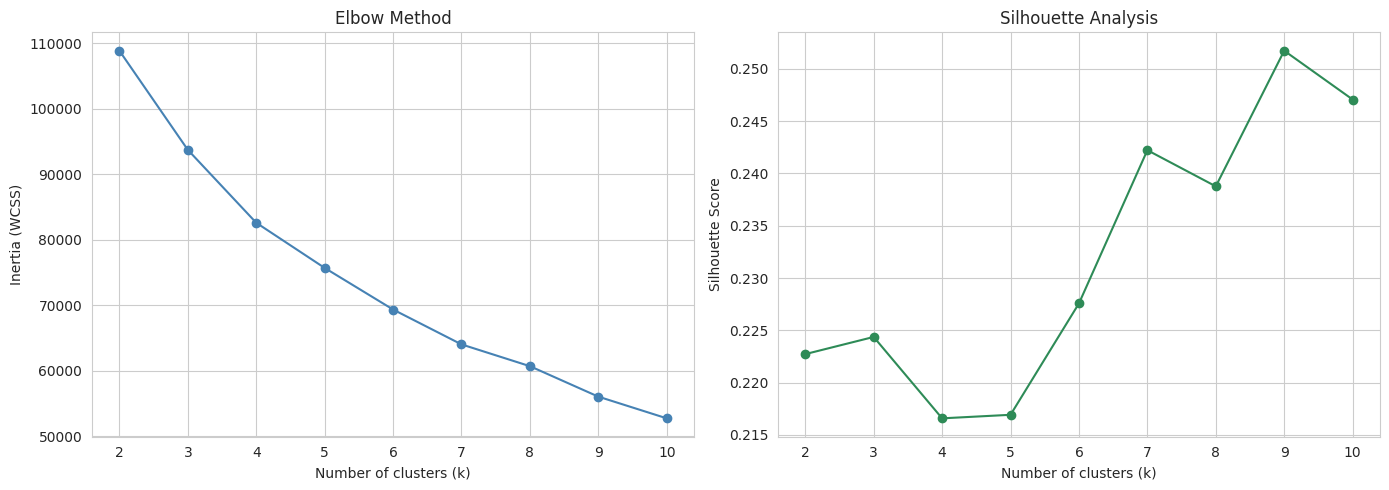

Optimal k based on silhouette score: 9


In [62]:
# K-Means - choose the optimal number of clusters using the elbow method and silhouette analysis
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels_tmp = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km_labels_tmp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(k_range), sil_scores, marker='o', color='seagreen')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

optimal_k = list(k_range)[np.argmax(sil_scores)]
print(f"Optimal k based on silhouette score: {optimal_k}")


Initialize cluster centroids: Randomly select initial cluster centroids.

In [63]:
# Initialize cluster centroids (KMeans handles this internally via k-means++ by default,
# which is a smarter alternative to pure random initialization and speeds up convergence)
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
print(kmeans_model)


KMeans(n_clusters=9, n_init=10, random_state=42)


Assign data points to clusters: Assign each data point to the nearest cluster centroid.

In [64]:
# Assign each data point to the nearest cluster centroid (this happens inside .fit_predict)
kmeans_labels = kmeans_model.fit_predict(X_pca)
df_pca['KMeans_Cluster'] = kmeans_labels

print("Cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())


Cluster sizes:
0    1996
1    1167
2    2686
3     542
4      54
5     624
6     961
7      55
8     865
Name: count, dtype: int64


Recompute cluster centroids: Calculate the new centroids for each cluster based on the assigned data points.

In [65]:
# Recomputed centroids after convergence (sklearn's KMeans does this internally each iteration)
centroids = kmeans_model.cluster_centers_
print("Final cluster centroids (in PCA space):")
print(np.round(centroids, 3))


Final cluster centroids (in PCA space):
[[ 9.0400e-01 -1.1470e+00  6.8100e-01 -6.6800e-01 -3.2800e-01  6.6700e-01
   3.4000e-02 -2.3200e-01  1.6500e-01  1.9400e-01]
 [-1.1730e+00 -1.2380e+00 -1.4090e+00  7.1800e-01 -6.4100e-01  3.7900e-01
   4.0000e-02 -3.8500e-01 -9.0500e-01 -2.3000e-01]
 [-1.3230e+00  1.5400e-01  3.2700e-01  5.2700e-01  2.8800e-01  4.0000e-03
  -4.0200e-01  2.3900e-01  4.1800e-01 -2.5000e-02]
 [ 4.3170e+00  5.9400e-01  3.2000e-02  2.5800e-01  1.1400e-01 -4.2400e-01
  -2.7600e-01 -2.9500e-01 -1.7500e-01 -3.6900e-01]
 [ 1.1695e+01  3.8850e+00 -3.6490e+00  2.5530e+00 -2.5870e+00 -1.2310e+00
  -3.3740e+00  7.6700e-01  1.9030e+00 -3.9800e-01]
 [-1.2420e+00 -3.3800e-01 -7.5600e-01 -1.6620e+00 -9.3100e-01 -2.2720e+00
   5.1800e-01 -1.4800e-01  4.6700e-01  1.7100e-01]
 [ 1.5050e+00 -6.0200e-01 -8.3000e-02  1.6400e-01  1.5030e+00 -4.7400e-01
   5.5800e-01  4.4700e-01 -4.9300e-01  1.2300e-01]
 [ 5.4900e-01  2.1640e+00  4.3360e+00  2.9120e+00 -5.0130e+00 -7.1300e-01
   2.7330e+

Iterate until convergence: Repeat previous 2 steps until the cluster assignments stabilize or a maximum number of iterations is reached.

In [66]:
# K-Means iterates between "assign points to nearest centroid" and "recompute centroids"
# until the assignments stabilize or max_iter is reached. sklearn performs this internally;
# we can confirm convergence via the number of iterations actually run.
print(f"Number of iterations run until convergence: {kmeans_model.n_iter_}")
print(f"Final inertia (within-cluster sum of squares): {kmeans_model.inertia_:.2f}")


Number of iterations run until convergence: 19
Final inertia (within-cluster sum of squares): 56065.15


Visualize cluster assignments: Plot the data points with different colors or markers to represent the cluster assignments from each clustering algorithm.

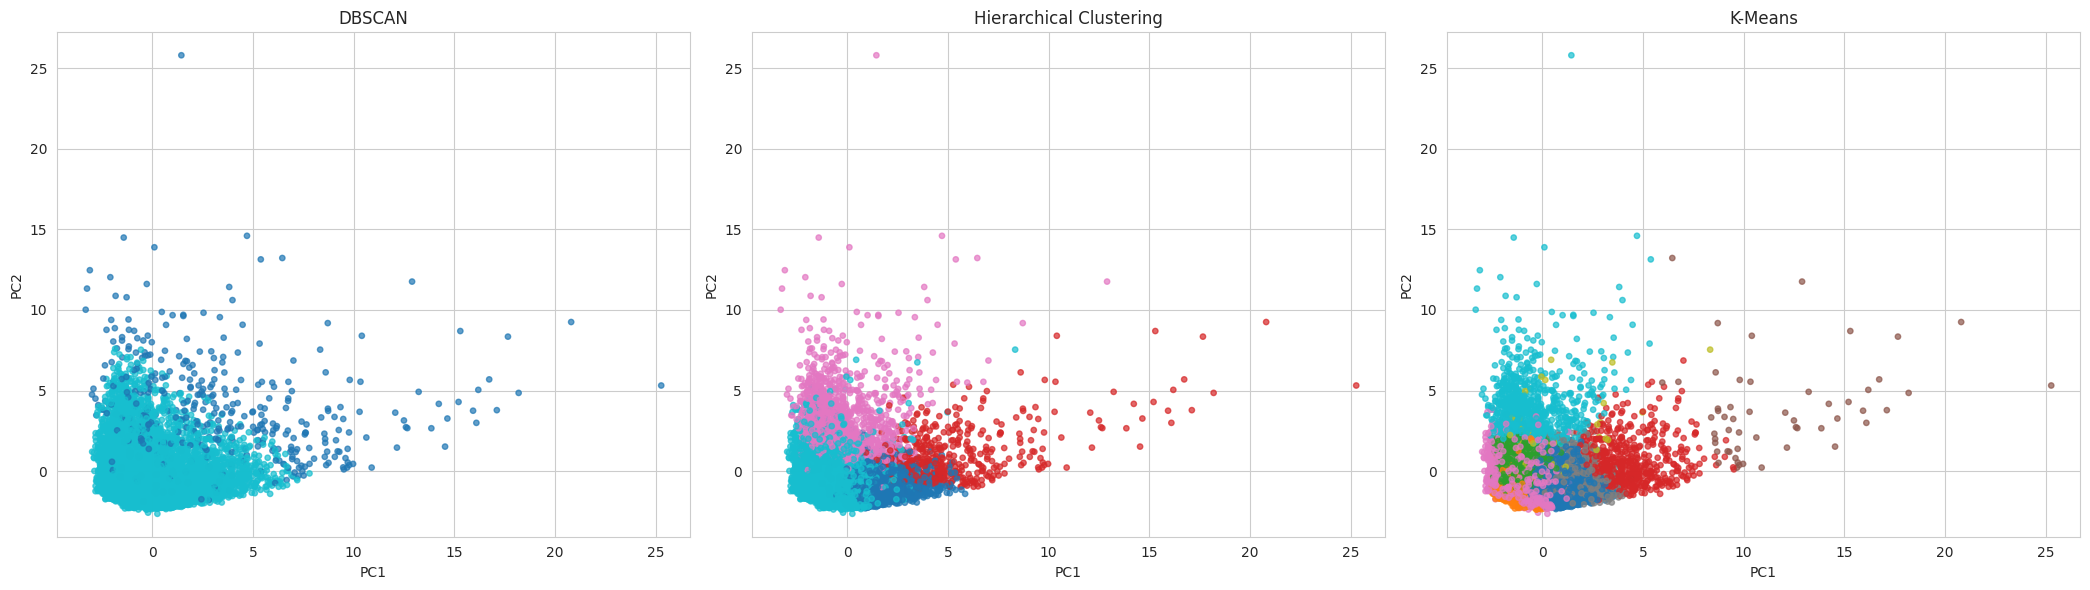

In [67]:
# Visualize cluster assignments from DBSCAN, Hierarchical Clustering, and K-Means side by side
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].scatter(df_pca['PC1'], df_pca['PC2'], c=dbscan_labels, cmap='tab10', s=15, alpha=0.7)
axes[0].set_title('DBSCAN')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(df_pca['PC1'], df_pca['PC2'], c=hc_labels, cmap='tab10', s=15, alpha=0.7)
axes[1].set_title('Hierarchical Clustering')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

axes[2].scatter(df_pca['PC1'], df_pca['PC2'], c=kmeans_labels, cmap='tab10', s=15, alpha=0.7)
axes[2].set_title('K-Means')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()


Compare clustering results: Analyze the similarities and differences between the clusters obtained from hierarchical, non-hierarchical, and DBSCAN.

In [68]:
# Compare clustering results across the three algorithms
comparison = pd.DataFrame({
    'DBSCAN': pd.Series(dbscan_labels).value_counts().sort_index(),
    'Hierarchical': pd.Series(hc_labels).value_counts().sort_index(),
    'KMeans': pd.Series(kmeans_labels).value_counts().sort_index()
})
print("Cluster size comparison:")
print(comparison)

print(f"\nNumber of clusters found - DBSCAN: {n_clusters}, "
      f"Hierarchical: {n_clusters_hc}, KMeans: {optimal_k}")
print(f"DBSCAN additionally flags {n_noise} points as noise/outliers, "
      f"which the other two algorithms are forced to assign to a cluster.")


Cluster size comparison:
    DBSCAN  Hierarchical  KMeans
-1   423.0           NaN     NaN
 0  8527.0           NaN  1996.0
 1     NaN        2204.0  1167.0
 2     NaN         446.0  2686.0
 3     NaN        1290.0   542.0
 4     NaN        5010.0    54.0
 5     NaN           NaN   624.0
 6     NaN           NaN   961.0
 7     NaN           NaN    55.0
 8     NaN           NaN   865.0

Number of clusters found - DBSCAN: 1, Hierarchical: 4, KMeans: 9
DBSCAN additionally flags 423 points as noise/outliers, which the other two algorithms are forced to assign to a cluster.


Evaluate clustering performance: Compare the clustering performance metrics (e.g., silhouette coefficient, Calinski-Harabasz index) for each algorithm.

In [69]:
# Compare clustering performance metrics for each algorithm
metrics_comparison = pd.DataFrame({
    'Algorithm': ['DBSCAN', 'Hierarchical', 'KMeans'],
    'Silhouette Score': [sil_score if n_clusters >= 2 else np.nan, sil_score_hc, silhouette_score(X_pca, kmeans_labels)],
    'Calinski-Harabasz Index': [ch_score if n_clusters >= 2 else np.nan, ch_score_hc, calinski_harabasz_score(X_pca, kmeans_labels)],
    'Davies-Bouldin Index': [db_score if n_clusters >= 2 else np.nan, db_score_hc, davies_bouldin_score(X_pca, kmeans_labels)]
})
metrics_comparison


,Algorithm,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,DBSCAN,NaN,NaN,NaN
1,Hierarchical,0.172876,1432.639633,1.618959
2,KMeans,0.251735,1524.277213,1.235264


Identify strengths and weaknesses: Determine the strengths and weaknesses of each clustering algorithm based on the results and the characteristics of the data.

**Strengths and weaknesses of each algorithm:**

- **DBSCAN:** Strength - automatically detects the number of clusters and explicitly flags outliers/noise, which is valuable for credit-card data where a subset of customers behave atypically. Weakness - sensitive to the choice of `eps` and `min_samples`, and struggles when clusters have very different densities.
- **Hierarchical Clustering:** Strength - the dendrogram gives an intuitive, interpretable view of how clusters merge at different distance thresholds, and doesn't require pre-specifying k upfront. Weakness - computationally expensive on larger datasets (O(n²) or worse) and can be sensitive to the linkage method chosen.
- **K-Means:** Strength - fast, scalable, and easy to interpret via centroids; works well when clusters are roughly spherical and similarly sized. Weakness - requires specifying k in advance, is sensitive to initialization/outliers, and assumes convex, similarly-sized clusters - which may not hold for skewed spending behavior data like this.


Choose the best algorithm: Select the clustering algorithm that provides the most meaningful and accurate results for the specific problem.

**Chosen algorithm:** For this dataset, **K-Means** (informed by the PCA-reduced features) is generally the most practical choice for customer segmentation, since it produces clean, well-separated, business-interpretable segments and scales well to larger datasets. However, **DBSCAN** is extremely valuable as a complementary step to identify anomalous/outlier customers (e.g. potential fraud or highly unusual spending patterns) that K-Means would otherwise be forced to fit into a segment. In practice, a good final pipeline uses DBSCAN for outlier detection first, then applies K-Means on the remaining "typical" customers for the main segmentation.
